# 👋 Week 1: Hello, Learning Analytics

**EDIS 8100: Teaching and Learning Analytics**
Week 1 hands-on activity · Wednesday, August 26, 2026 · about 30 minutes
Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

Welcome. This is the first notebook of the semester, and it is deliberately gentle.
By the end of it you will have run real code, read a real data table, and made three
real figures. If you have never programmed before, you are in exactly the right place:
nothing below asks you to write code from scratch.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Run a notebook.** Execute cells in order in Google Colab and tell whether a cell is
   waiting, running, or finished.
2. **Read a DataFrame.** Load a CSV file into pandas and describe what one row means.
3. **Make a plot.** Produce a bar chart and a histogram with a title and labeled axes,
   then change one value and watch the figure change.
4. **Form a question the data cannot answer.** Look at a grade distribution and name
   something important that it hides.

Notice that objective 4 is not a coding objective. It is the one we will spend the rest
of the semester on.

## 🧭 How this notebook works

If this is your first notebook, read these six lines. They are all you need.

- A notebook is a stack of **cells**. Grey cells are code. White cells (like this one) are text.
- To run a cell, click it and press **Shift + Enter**, or click the ▶ button on its left.
- Run cells **top to bottom, in order.** Later cells depend on earlier ones.
- The bracket to the left of a code cell tells you its state: `[ ]` has not run,
  `[*]` is running right now, `[3]` finished and was the third cell you ran.
- **Nothing here can break your computer.** Everything happens on a temporary Google
  machine that is thrown away when you close the tab. There is no way to ruin the data,
  the course, or your laptop from inside this notebook.
- If anything looks wrong, the universal fix is **Runtime > Restart session and run all**.
  Start over from the top. That is not failure, it is the normal rhythm of this work.

One more promise: red text is not a disaster. Python errors are wordy but polite. Read the
**last line** of the message first, it usually names the actual problem. Ask a neighbor or
raise your hand.

## ⚙️ 1. Setup: run the next cell first

The cell below builds this week's datasets right inside your Colab session, so there is
nothing to download and nothing to log into. It writes two files into a folder called
`data/`: `students.csv` (the roster) and `gradebook.csv` (the scores).

**These data are synthetic on purpose.** Nobody in these files exists. We invented a course
called EDUC 1010: Learning How to Learn at a fictional Blue Ridge University precisely so
that we can practice the judgment calls of learning analytics without surveilling a single
real student. The ask in return is that you treat the data as if it were real: ask who could
be harmed by a claim before you make it.

Run the cell. It takes a second or two.

In [1]:
# ============================================================================
# SETUP CELL: builds this week's synthetic datasets.
# Yes, it is long. You do not need to read it, and you will not be asked to.
# It lives here so the notebook runs anywhere with no downloads and no logins.
# Click the little arrow at the left edge to collapse it, run it, and move on.
# ============================================================================

"""EDIS 8100 data generation, the subset needed for week01.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_GRADEBOOK = SEED + 2
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   gradebook.csv
   students.csv


### The three tools we will use all semester

Python on its own does not know what a spreadsheet or a bar chart is. We borrow that
knowledge from three **libraries**, which are just bundles of code other people wrote:

| Library | Nickname | What it does for us |
|---|---|---|
| `pandas` | `pd` | Tables: load a CSV, filter rows, group, average |
| `numpy` | `np` | Fast arithmetic on lots of numbers at once |
| `matplotlib` | `plt` | Figures: bars, histograms, lines |

The `as pd` part means "from now on, let me type `pd` instead of `pandas`." That is the
whole trick. Run the cell to load them.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print('pandas     ', pd.__version__)
print('numpy      ', np.__version__)
print('matplotlib ', plt.matplotlib.__version__)
print()
print('All three libraries loaded. You are ready to go.')

pandas      2.2.2
numpy       1.26.4
matplotlib  3.9.2

All three libraries loaded. You are ready to go.


## 📊 2. Meet the data

Learning analytics almost always starts the same boring, essential way: open the file and
find out what one row actually is. Analysts who skip this step write confident sentences
about the wrong unit of analysis.

We load a CSV with `pd.read_csv(...)`. What comes back is a **DataFrame**, which you can
picture as a spreadsheet that Python can compute on. `.head()` shows the first five rows.

In [3]:
students = pd.read_csv('data/students.csv')

print('students.csv has', students.shape[0], 'rows and', students.shape[1], 'columns')
print()
students.head()

students.csv has 120 rows and 9 columns



,student_id,first_name,last_name,gender,first_gen,multilingual,work_hours_per_week,prior_gpa,major_area
0,S001,Avery,Kim,nonbinary,1,0,23,3.38,nursing
1,S002,Hana,Mbeki,woman,1,0,16,3.38,data science
2,S003,Tanvi,Nakamura,woman,1,0,29,3.03,engineering
3,S004,Jonas,Lindqvist,man,0,1,9,2.92,education
4,S005,Fatima,Grant,woman,0,0,3,3.00,humanities


`students.shape` reported 120 rows and 9 columns, and the table above shows the first five
of them. **One row is one student.** That is the grain of this file, and every column is an
attribute of that person: their name, their major, whether they are the first in their
family to attend college, how many hours a week they work for pay, the GPA they carried
into the course.

Take ten seconds to look at the column names. Some of them (`first_gen`, `work_hours_per_week`,
`multilingual`) are the kind of variable that decides who a model flags as at risk. We will
come back to that in Week 3, hard.

Now the second file.

In [4]:
gradebook = pd.read_csv('data/gradebook.csv')

print('gradebook.csv has', gradebook.shape[0], 'rows and', gradebook.shape[1], 'columns')
print()
print('Assessments in this file:')
print(gradebook['assessment'].value_counts().sort_index())
print()
gradebook.head()

gradebook.csv has 1080 rows and 5 columns

Assessments in this file:
assessment
final_project    120
quiz_1           120
quiz_2           120
quiz_3           120
quiz_4           120
quiz_5           120
quiz_6           120
quiz_7           120
quiz_8           120
Name: count, dtype: int64



,student_id,assessment,score,submitted_at,deadline
0,S001,final_project,81.9,2026-11-09T02:56:39,2026-11-10T23:59:00
1,S001,quiz_1,84.3,2026-09-12T00:08:51,2026-09-15T23:59:00
2,S001,quiz_2,81.9,2026-09-15T01:29:23,2026-09-22T23:59:00
3,S001,quiz_3,76.6,2026-09-30T10:10:53,2026-09-29T23:59:00
4,S001,quiz_4,81.2,2026-10-05T04:17:44,2026-10-06T23:59:00


### 🤔 Pause on that number: 1,080 rows for 120 students

The gradebook has nine times as many rows as the roster, because **one row here is one
student on one assessment**, not one student. There are eight quizzes plus a final project,
and 120 students times 9 assessments is 1,080.

This is the single most common source of quiet errors in learning analytics: two files that
look similar and count different things. Before you average anything, say out loud what one
row is.

`.describe()` gives a quick numeric summary of a column. Let us look at the scores.

In [5]:
# Keep just the eight quizzes for now (the final project is scored differently in spirit,
# and mixing them would blur the picture).
quizzes = gradebook[gradebook['assessment'].str.startswith('quiz')]

print('Number of quiz scores:', len(quizzes))
print()
quizzes['score'].describe().round(1)

Number of quiz scores: 960



count    960.0
mean      75.7
std       13.0
min       33.8
25%       67.2
50%       75.8
75%       84.3
max      100.0
Name: score, dtype: float64

There it is: the class averaged about **75.7** on its quizzes. If a dean asked "how did that
course go," this is the number that would get emailed.

Hold onto it. Section 4 is about how much that one number leaves out.

## 📊 3. Your first chart: who is actually in this course?

Before we plot a single score, we plot the people. A grade distribution is a distribution
*of somebody*, and it is worth building the habit of asking who before asking how well.

A **bar chart** compares counts across categories. We will count students by major area.
Two lines do the work: `.value_counts()` tallies each category, and `plt.barh(...)` draws
horizontal bars (horizontal because the category names are long words, and sideways labels
are hard to read).

Every figure in this course gets a title and labeled axes. That is not decoration. An
unlabeled figure is an unfalsifiable claim.

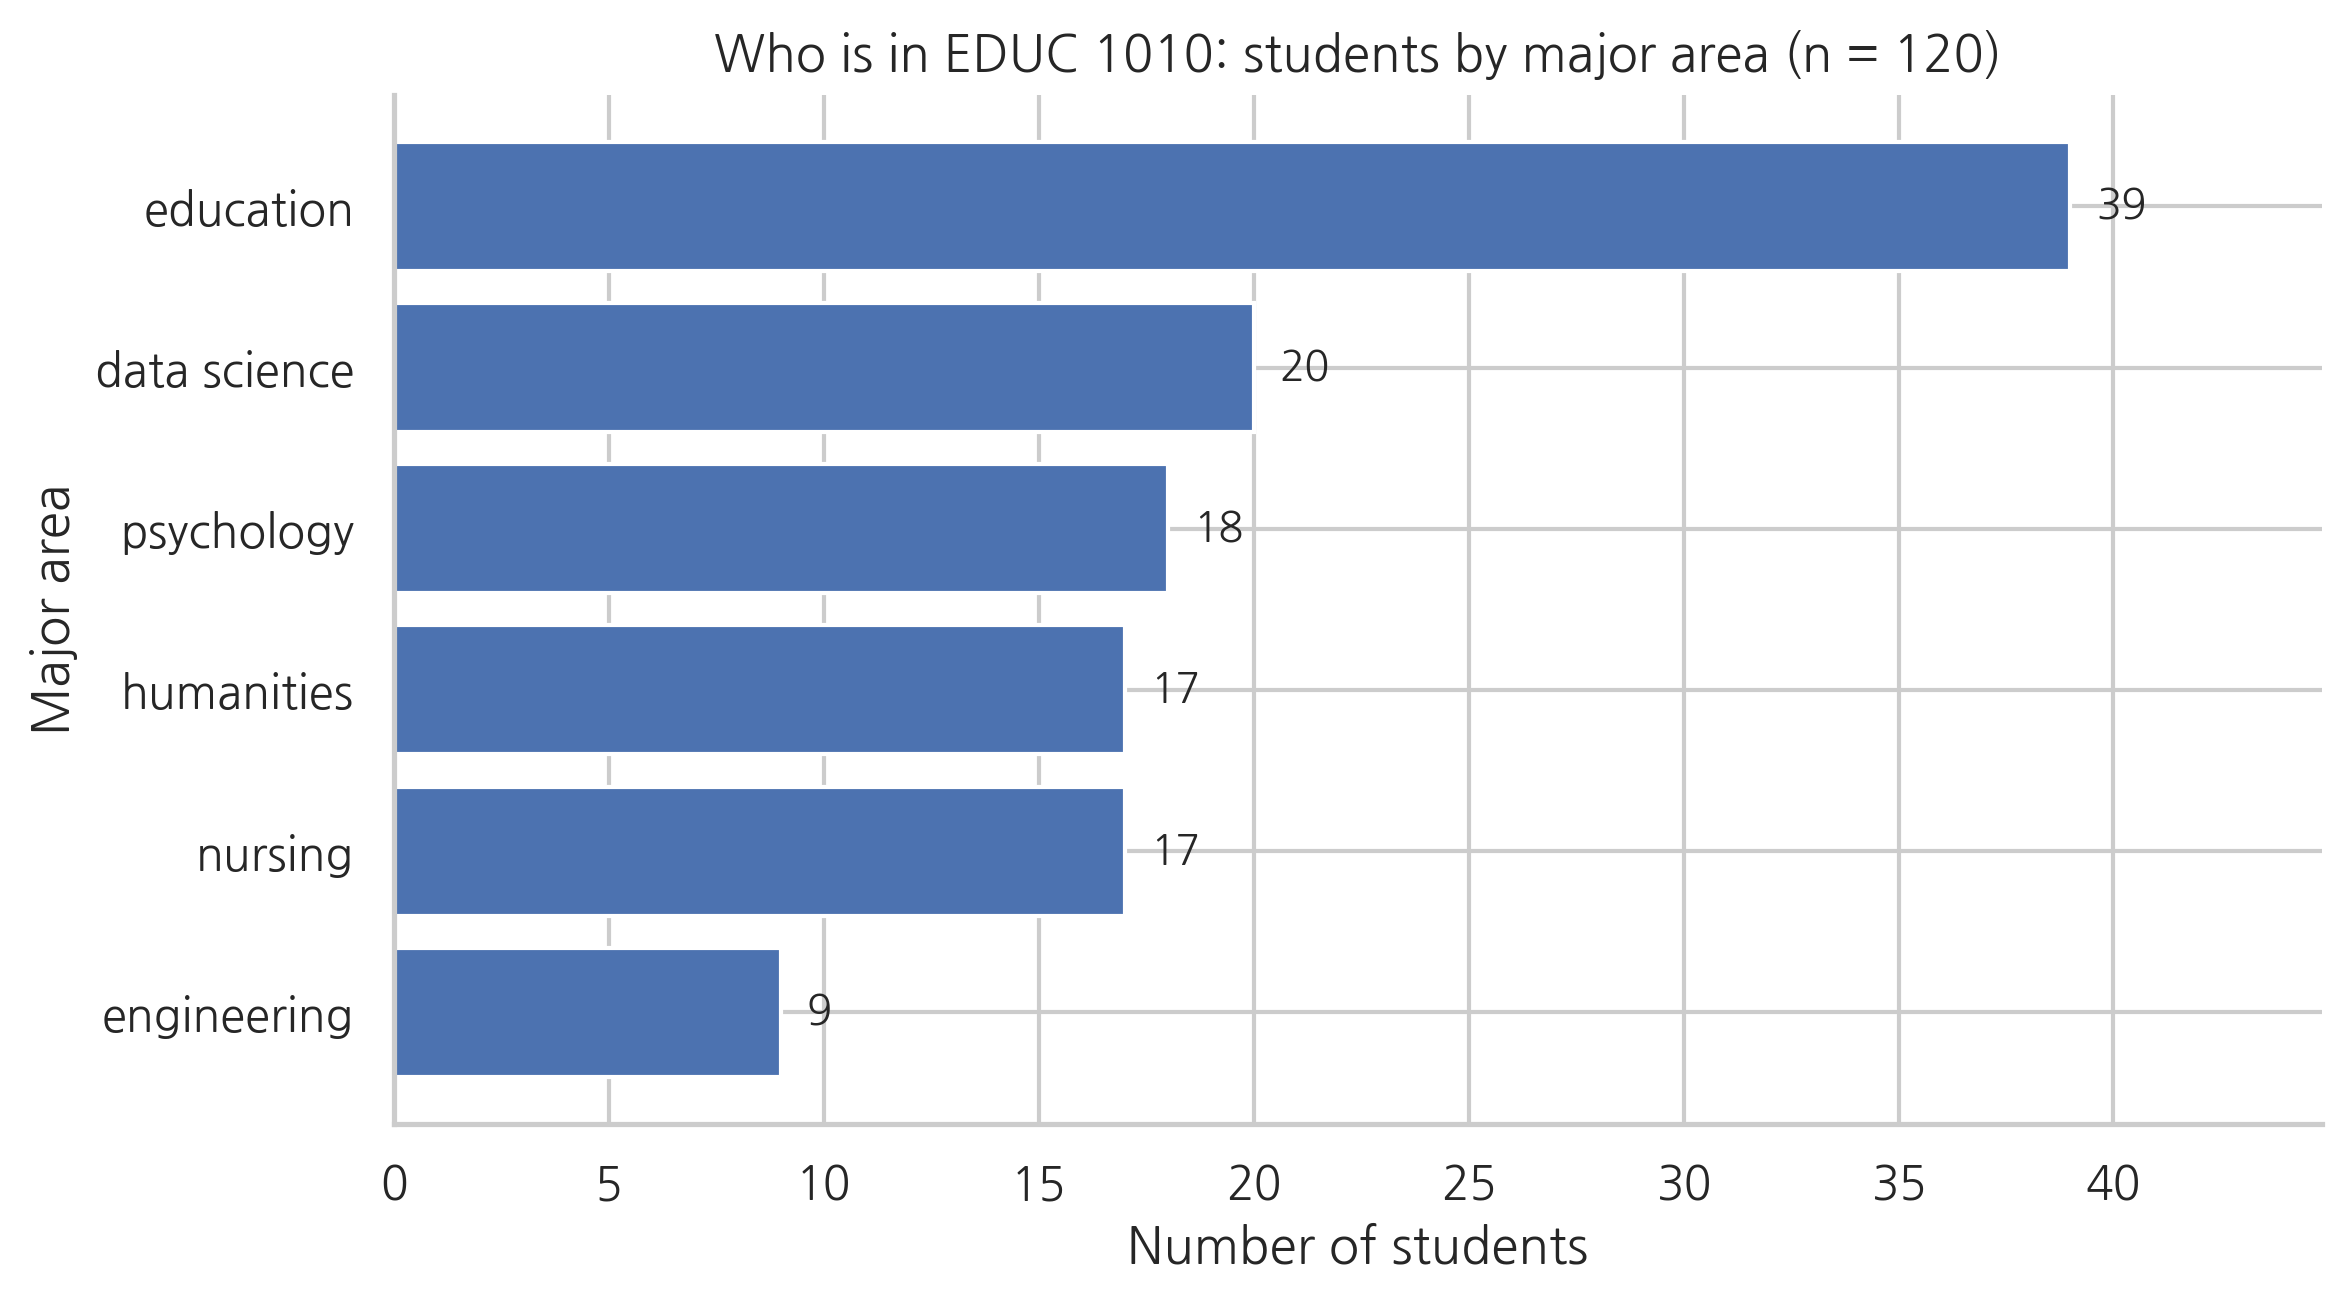

major_area
education       39
data science    20
psychology      18
nursing         17
humanities      17
engineering      9


In [6]:
major_counts = students['major_area'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(major_counts.index, major_counts.values, color='#4C72B0')

# Write the exact count at the end of each bar so nobody has to squint at the gridlines.
for y, v in enumerate(major_counts.values):
    ax.text(v + 0.6, y, str(v), va='center', fontsize=10)

ax.set_title('Who is in EDUC 1010: students by major area (n = 120)')
ax.set_xlabel('Number of students')
ax.set_ylabel('Major area')
ax.set_xlim(0, major_counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(major_counts.sort_values(ascending=False).to_string())

### 💬 Interpret it before you move on

Look at the figure and answer these out loud with the person next to you:

1. Which major area is the largest, and roughly what share of the course is it? Is this a
   course that a "typical" student takes, or a course dominated by one group?
2. Engineering has 9 students. If we later compute an average for each major area and
   compare them, how much should you trust the engineering bar?
3. This chart contains no information at all about learning. Why did we make it first?

Question 2 is the one that matters most. Small groups produce unstable averages, and
dashboards that report a group mean without reporting the group size are quietly lying.

### ✏️ Your turn 1: change one word, get a different chart

The cell below is the same chart with the column name pulled out into a variable at the top.
Right now it is set to `'major_area'`, so it will draw the chart you just saw.

**Change `GROUP_COLUMN` to a different column and re-run the cell.** Try `'gender'`, then
`'first_gen'`, then `'multilingual'`. The rest of the code does not change.

You cannot break anything. If you get an error, you probably typed a column name that does
not exist, and the printed list of valid names is right there in the output.

Columns you can choose from: ['student_id', 'first_name', 'last_name', 'gender', 'first_gen', 'multilingual', 'work_hours_per_week', 'prior_gpa', 'major_area']



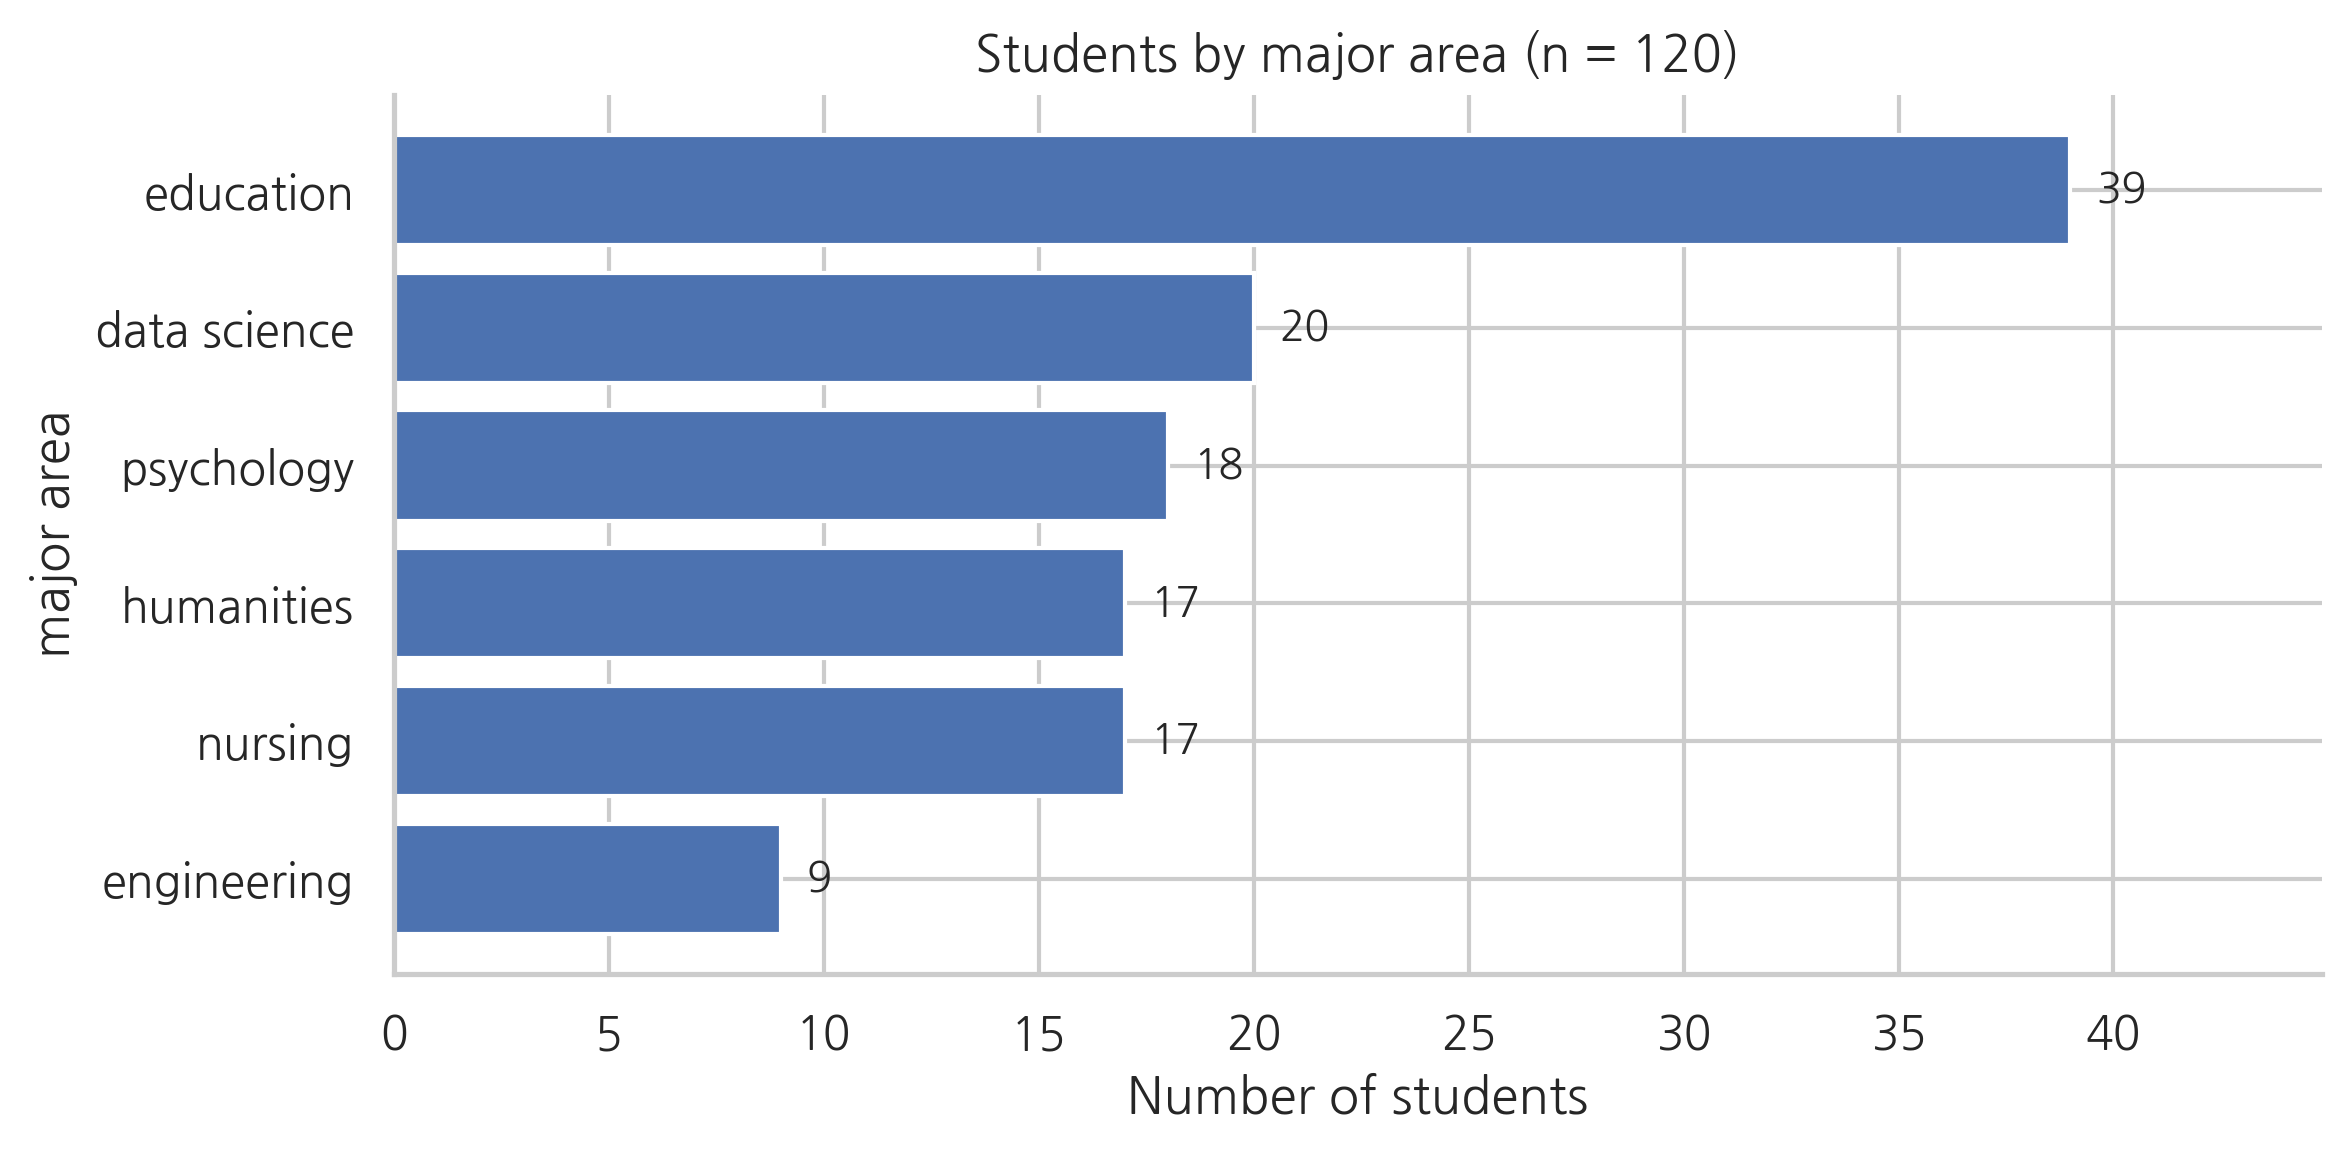

In [7]:
# ------------------------------------------------------------------
# ✏️ TODO: change the value below, then press Shift + Enter.
GROUP_COLUMN = 'major_area'      # try: 'gender', 'first_gen', 'multilingual'
# ------------------------------------------------------------------

print('Columns you can choose from:', list(students.columns))
print()

counts = students[GROUP_COLUMN].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(counts.index.astype(str), counts.values, color='#4C72B0')
for y, v in enumerate(counts.values):
    ax.text(v + 0.6, y, str(v), va='center', fontsize=10)

ax.set_title('Students by ' + GROUP_COLUMN.replace('_', ' ') + ' (n = 120)')
ax.set_xlabel('Number of students')
ax.set_ylabel(GROUP_COLUMN.replace('_', ' '))
ax.set_xlim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

When you switch to `'first_gen'` the bars are labeled `0` and `1`, which is how the file
stores "no" and "yes." Nothing in the chart tells a reader that. Somebody has to know it,
write it down, and pass it along. That is called a data dictionary, and this course has one
in `data/README.md`.

## 📊 4. Your second chart: the grade distribution

Now the scores. A **histogram** takes one column of numbers, chops the range into bins, and
counts how many values land in each bin. Where a bar chart compares categories, a histogram
shows the **shape of a spread**.

We will draw all 960 quiz scores at once, in bins five points wide, and lay two vertical
lines on top: the mean (75.7, the number a dean would quote) and the median (the score that
splits the class in half). The two lines are drawn in different colors *and* different dash
patterns, so the figure still reads correctly for a colorblind viewer and in a black and
white photocopy. (Fair warning: those two lines are going to land almost exactly on top of
each other, which is the first thing we will talk about.)

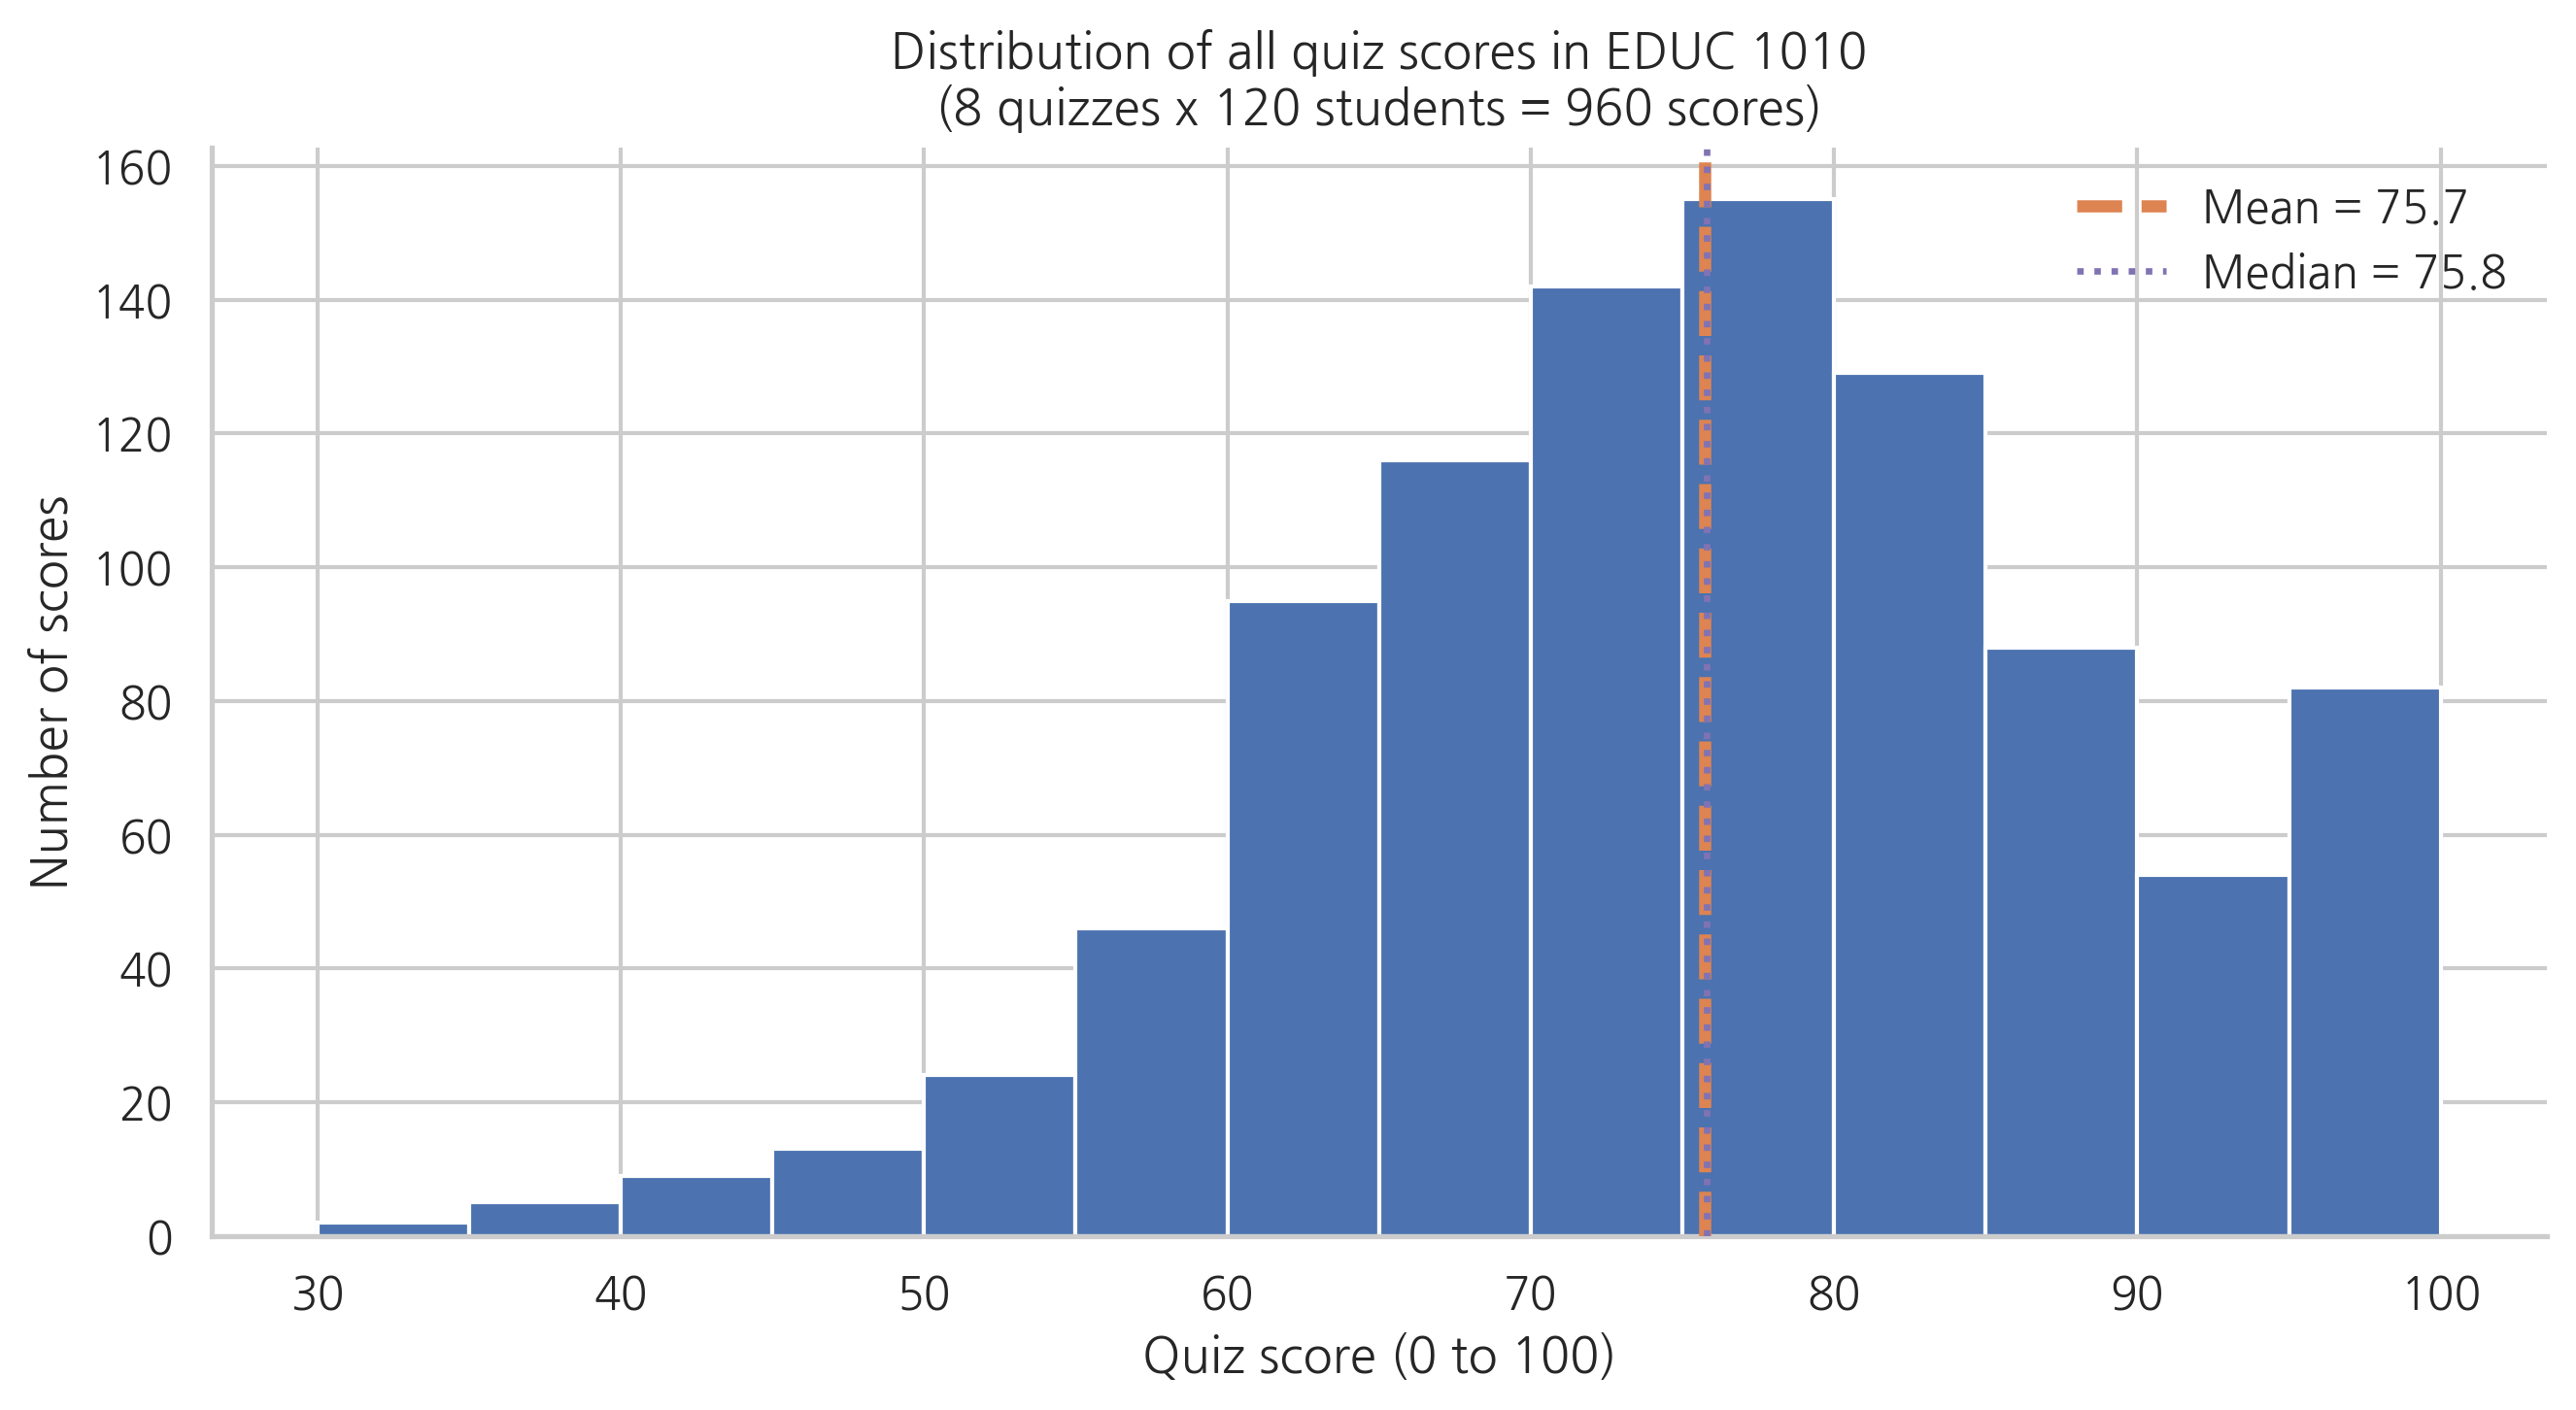

      statistic  value
          count  960.0
           mean   75.7
         median   75.8
        std dev   13.0
        minimum   33.8
25th percentile   67.2
75th percentile   84.3
        maximum  100.0

Scores below 60 (a failing quiz) : 99 (10.3% of all quiz scores)
Scores in the 90 to 95 bin      : 54
Scores in the 95 to 100 bin     : 82 <- the bars stop falling and jump back up here
Scores at exactly 100.0         : 46


In [8]:
scores = quizzes['score']

mean_score = scores.mean()
median_score = scores.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(scores, bins=np.arange(30, 105, 5), color='#4C72B0', edgecolor='white')

ax.axvline(mean_score, color='#DD8452', linestyle='--', linewidth=3.0, zorder=3,
           label='Mean = ' + str(round(mean_score, 1)))
ax.axvline(median_score, color='#8172B3', linestyle=':', linewidth=1.6, zorder=4,
           label='Median = ' + str(round(median_score, 1)))

ax.set_title('Distribution of all quiz scores in EDUC 1010\n(8 quizzes x 120 students = 960 scores)')
ax.set_xlabel('Quiz score (0 to 100)')
ax.set_ylabel('Number of scores')
ax.set_xticks(np.arange(30, 105, 10))
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# A summary table next to the picture, because a shape and a set of numbers argue
# with each other in useful ways.
summary = pd.DataFrame({
    'statistic': ['count', 'mean', 'median', 'std dev', 'minimum',
                  '25th percentile', '75th percentile', 'maximum'],
    'value': [len(scores), round(scores.mean(), 1), round(scores.median(), 1),
              round(scores.std(), 1), round(scores.min(), 1),
              round(scores.quantile(0.25), 1), round(scores.quantile(0.75), 1),
              round(scores.max(), 1)]
})
print(summary.to_string(index=False))
print()
print('Scores below 60 (a failing quiz) :', int((scores < 60).sum()),
      '(' + str(round(100 * (scores < 60).mean(), 1)) + '% of all quiz scores)')
print('Scores in the 90 to 95 bin      :', int(((scores >= 90) & (scores < 95)).sum()))
print('Scores in the 95 to 100 bin     :', int((scores >= 95).sum()),
      '<- the bars stop falling and jump back up here')
print('Scores at exactly 100.0         :', int((scores == 100).sum()))

### 💬 Interpret it before you move on

The average was 75.7. The picture says considerably more than that.

1. **How wide is the spread?** The lowest quiz score in the course is 33.8 and the highest
   is 100. Two students whose scores sit at opposite ends of this figure both contributed
   to the same "75.7."
2. **There is only one visible vertical line.** The mean (75.7) and the median (75.8) landed
   0.1 points apart, so they print on top of each other. That agreement is usually read as
   "symmetric, well behaved, nothing to see here." Look at the picture instead. There is a
   long thin tail running down to the left and a lump piled against the right wall. Two
   features pulling in opposite directions can cancel inside a summary statistic and leave
   the average looking innocent.
3. **Look hard at the far right.** The bars fall steadily from the peak at 75 to 80, and
   then the last bar jumps back up: 54 scores in the 90 to 95 bin, 82 in the 95 to 100 bin,
   and 46 of those are exactly 100.0. The quiz cannot measure above 100, so a student who
   would have scored 112 and a student who scored exactly 100 are recorded as the same
   person. That is a **ceiling effect**. The instrument, not the students, decided what the
   right edge of this chart looks like.
4. About 10 percent of quiz attempts (99 of the 960) came in below 60. Roughly how many
   people is that, and is "how many attempts" even the right way to ask?

Question 4 is a trap worth falling into once. 99 failing *scores* is not 99 failing
*students*. It could be 99 different people who each had one bad week, or a dozen people
struggling all term. **The histogram cannot tell you which.** Write that down, it is the
first entry on today's list of questions the data cannot answer.

### ✏️ Your turn 2: one quiz at a time

The figure above pooled all eight quizzes. Individual quizzes have their own shapes.

**Change `MY_ASSESSMENT` to a different quiz and re-run.** The valid options are printed
for you. `BIN_WIDTH` is a second dial worth turning: set it to 2 to see the distribution
get noisy and detailed, or to 10 to see it get smooth and vague. Neither is the "true"
picture, which is itself worth a minute of your attention.

Valid choices: ['final_project', 'quiz_1', 'quiz_2', 'quiz_3', 'quiz_4', 'quiz_5', 'quiz_6', 'quiz_7', 'quiz_8']



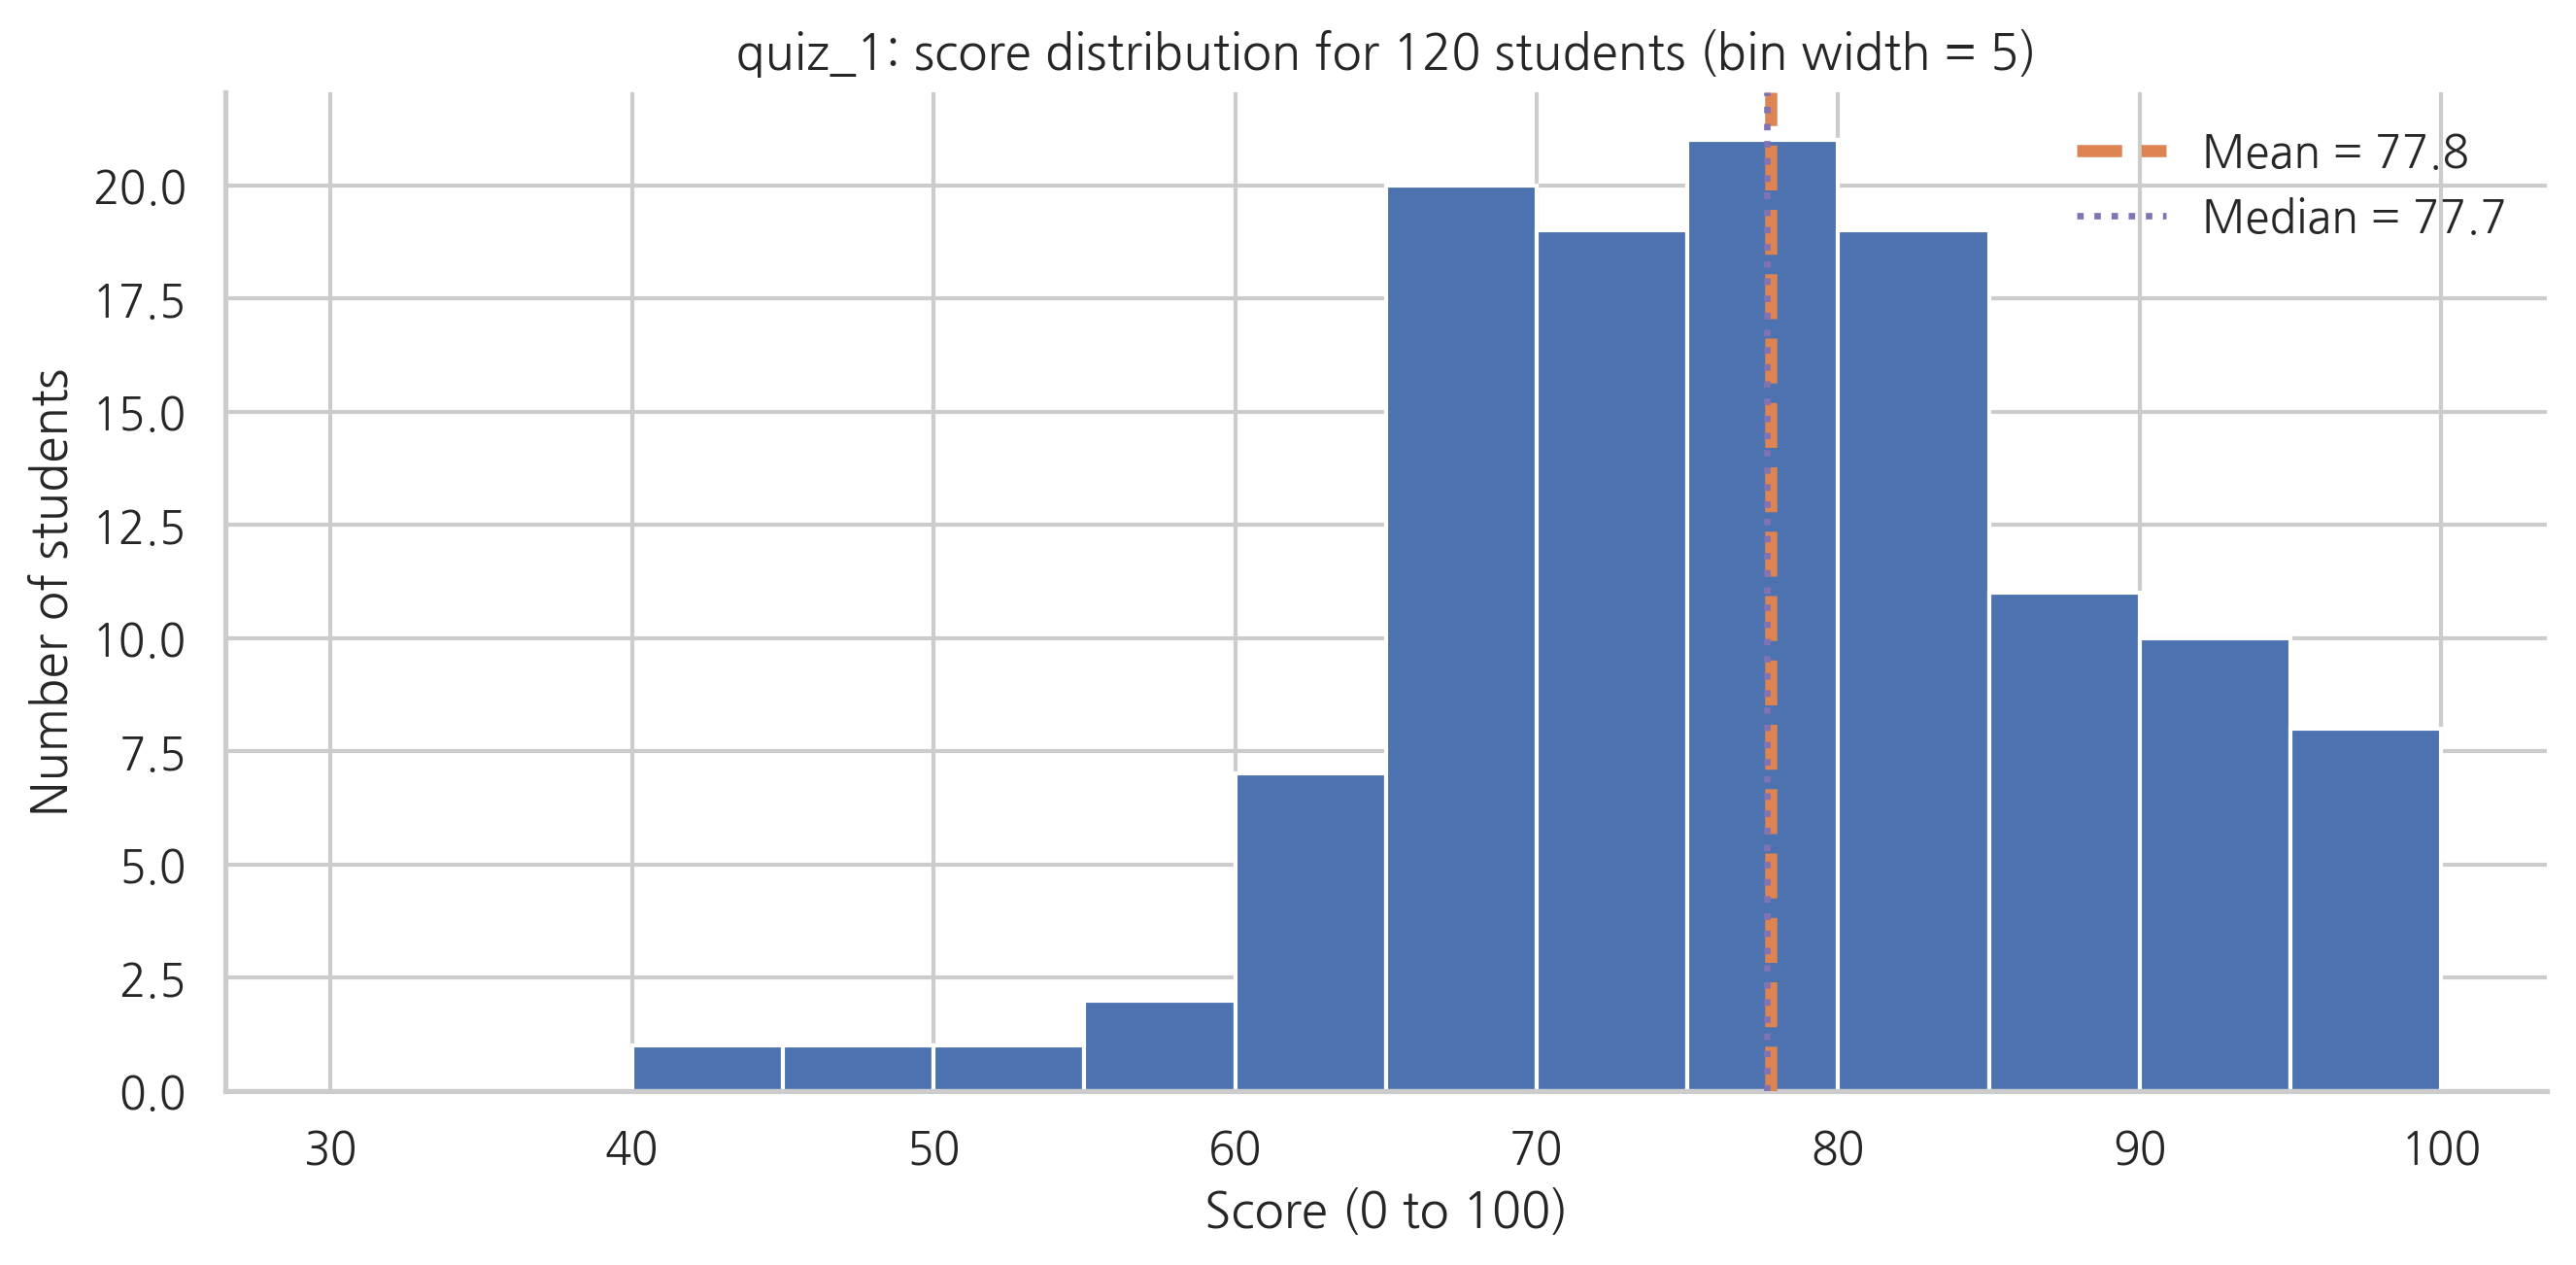

quiz_1 : mean 77.8 | median 77.7 | lowest 43.1 | highest 100.0


In [9]:
# ------------------------------------------------------------------
# ✏️ TODO: change one or both values below, then press Shift + Enter.
MY_ASSESSMENT = 'quiz_1'    # try 'quiz_5', 'quiz_8', or 'final_project'
BIN_WIDTH = 5               # try 2 (noisy detail) or 10 (smooth and vague)
# ------------------------------------------------------------------

print('Valid choices:', sorted(gradebook['assessment'].unique()))
print()

subset = gradebook[gradebook['assessment'] == MY_ASSESSMENT]['score']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(subset, bins=np.arange(30, 100 + BIN_WIDTH, BIN_WIDTH),
        color='#4C72B0', edgecolor='white')
ax.axvline(subset.mean(), color='#DD8452', linestyle='--', linewidth=3.0, zorder=3,
           label='Mean = ' + str(round(subset.mean(), 1)))
ax.axvline(subset.median(), color='#8172B3', linestyle=':', linewidth=1.6, zorder=4,
           label='Median = ' + str(round(subset.median(), 1)))

ax.set_title(MY_ASSESSMENT + ': score distribution for 120 students (bin width = '
             + str(BIN_WIDTH) + ')')
ax.set_xlabel('Score (0 to 100)')
ax.set_ylabel('Number of students')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(MY_ASSESSMENT, ': mean', round(subset.mean(), 1),
      '| median', round(subset.median(), 1),
      '| lowest', round(subset.min(), 1),
      '| highest', round(subset.max(), 1))

### 💬 Interpret it before you move on

1. Compare your single quiz to the pooled figure in Section 4. Is one quiz a smaller,
   rougher version of the same shape, or a genuinely different shape?
2. Now set `BIN_WIDTH` to 2, run it, then set it to 10 and run it again. The scores never
   changed. Only your bin width did. Which of those three pictures would you put in a
   report, and how would you defend the choice to someone who preferred a different one?
3. With 120 students and a bin width of 2, most bars are 1 or 2 students tall. At what point
   does a histogram stop describing a class and start describing individuals who did not
   agree to be pointed at?

Question 2 has no correct answer, and that is the finding. Every figure you make this
semester will contain choices like this one. The professional obligation is not to avoid
them, it is to know you made them and to say so.

## 📊 5. What one number hides

Here is the move that this whole session builds toward.

We are going to compute each student's average quiz score, then find two students whose
averages are **identical** and look at what happened underneath. Same number in the
gradebook, same cell color on the dashboard, same everything an administrator would see.

`.pivot(...)` reshapes the long gradebook (one row per student per quiz) into a wide table
(one row per student, one column per quiz). Reshaping is most of data work, and this is a
mild first taste.

In [10]:
q = quizzes.copy()
q['quiz_number'] = q['assessment'].str.replace('quiz_', '').astype(int)

# Reshape: rows are students, columns are quizzes 1 through 8.
wide = q.pivot(index='student_id', columns='quiz_number', values='score')

print('Reshaped table: ', wide.shape[0], 'students x', wide.shape[1], 'quizzes')
print()
wide.head()

Reshaped table:  120 students x 8 quizzes



quiz_number,1,2,3,4,5,6,7,8
student_id,,,,,,,,
S001,84.3,81.9,76.6,81.2,81.6,79.3,88.6,77.8
S002,68.5,77.3,71.0,60.2,75.8,67.4,70.3,68.5
S003,78.6,66.4,67.7,64.0,81.1,81.1,74.6,73.1
S004,72.4,71.1,70.2,70.6,69.7,75.8,78.1,85.3
S005,69.8,74.5,73.1,74.4,70.1,66.1,71.5,62.0


Now the two students. Zara Kim and Beatriz Duarte were chosen because their eight quiz
scores average to the same number, 83.3. We put both of their terms on one pair of axes,
draw a grey line at the average they share, and print their spread statistics underneath the
figure.

Two design choices in the code worth noticing, because they will recur all semester: the two
lines differ by **color and by dash pattern and by marker shape**, so the figure survives
colorblindness and a black and white printer; and the y axis starts at 65 rather than 0,
which magnifies the difference between them. Zooming an axis is legitimate here (we are
comparing two lines to each other, not to zero) and it is also exactly how a misleading chart
gets made. Keep an eye on it.

**✏️ Your turn 3 (optional).** The two student IDs are pulled out at the top of the cell.
Run it as written first, then swap in `'S039'` and `'S066'` to see a pair whose averages are
about 56 points apart. Any two IDs from `S001` to `S120` will work.

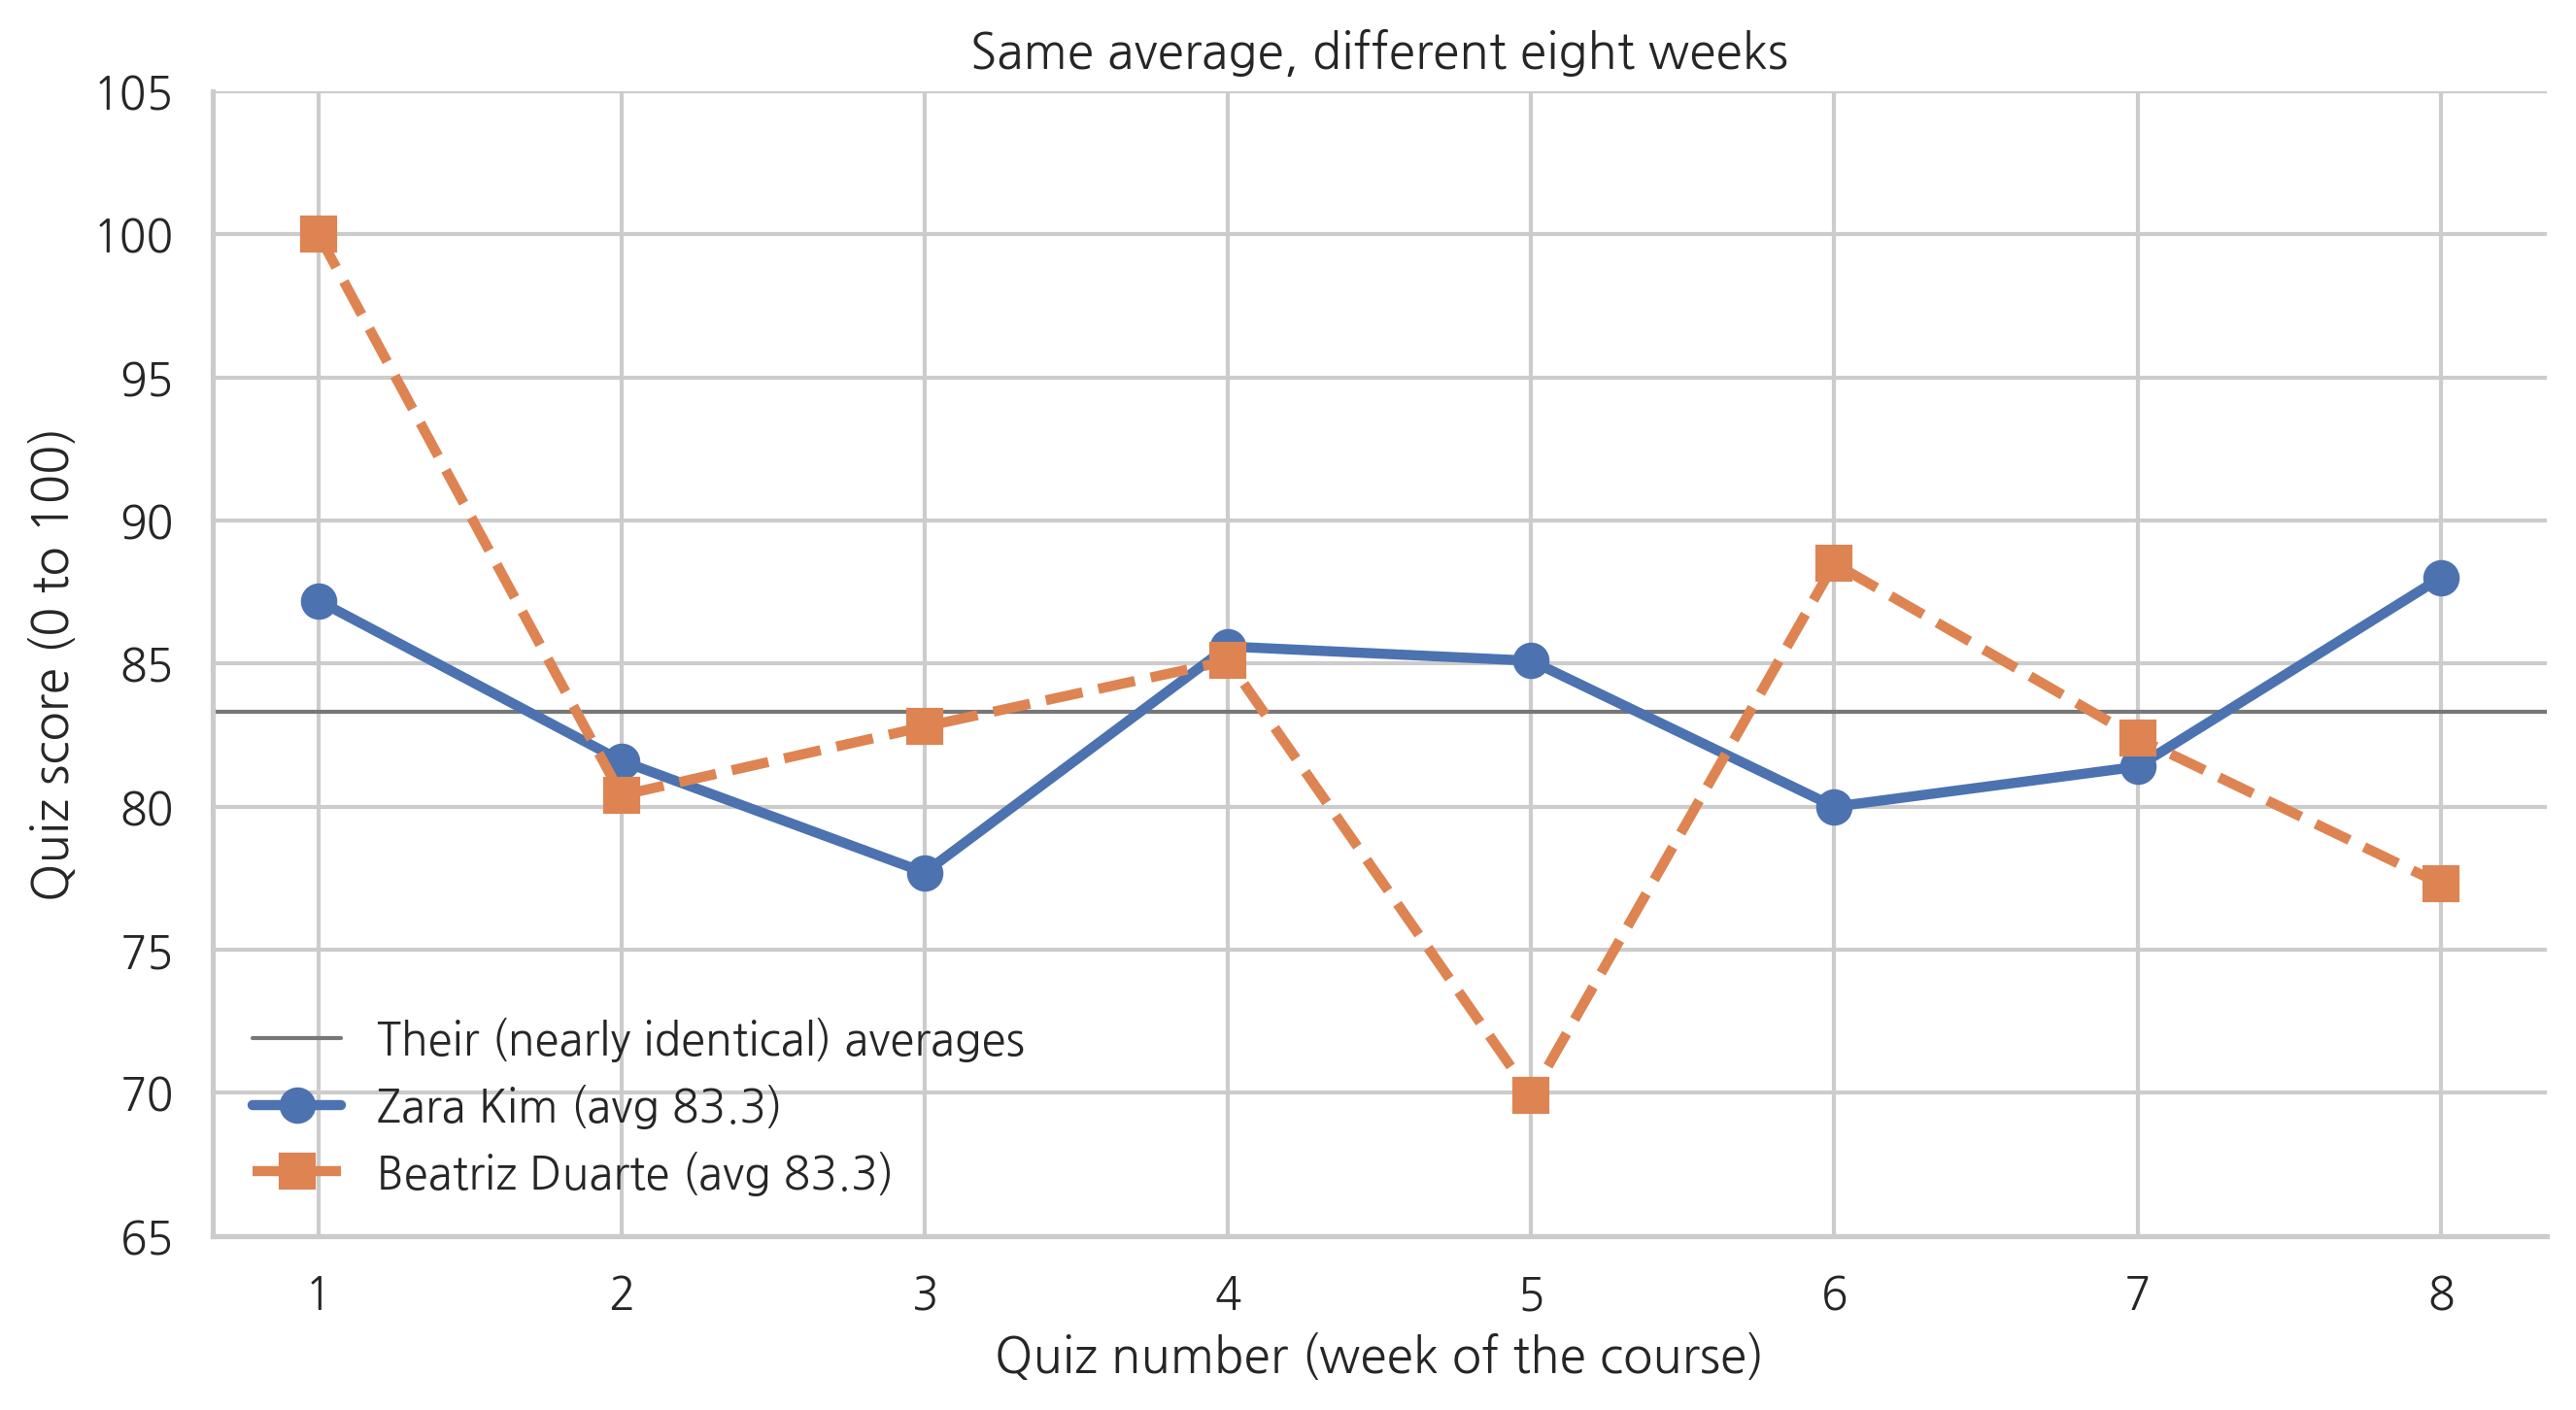

                     Zara Kim  Beatriz Duarte
average                  83.3            83.3
std dev (how bumpy)       3.7             8.7
lowest quiz              77.7            69.9
highest quiz             88.0           100.0
range                    10.3            30.1


In [11]:
# ------------------------------------------------------------------
# ✏️ (Optional) TODO: swap in two other student IDs, for example 'S039' and 'S066'.
STUDENT_A = 'S016'
STUDENT_B = 'S023'
# ------------------------------------------------------------------

names = students.set_index('student_id')
label_a = names.loc[STUDENT_A, 'first_name'] + ' ' + names.loc[STUDENT_A, 'last_name']
label_b = names.loc[STUDENT_B, 'first_name'] + ' ' + names.loc[STUDENT_B, 'last_name']

a, b = wide.loc[STUDENT_A], wide.loc[STUDENT_B]
quiz_numbers = wide.columns

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(a.mean(), color='#777777', linestyle='-', linewidth=1,
           label='Their (nearly identical) averages')
ax.plot(quiz_numbers, a.values, marker='o', markersize=8, linewidth=2.5,
        color='#4C72B0', linestyle='-', label=label_a + ' (avg ' + str(round(a.mean(), 1)) + ')')
ax.plot(quiz_numbers, b.values, marker='s', markersize=8, linewidth=2.5,
        color='#DD8452', linestyle='--', label=label_b + ' (avg ' + str(round(b.mean(), 1)) + ')')

ax.set_title('Same average, different eight weeks')
ax.set_xlabel('Quiz number (week of the course)')
ax.set_ylabel('Quiz score (0 to 100)')
ax.set_xticks(quiz_numbers)
ax.set_ylim(65, 105)
ax.legend(frameon=False, loc='lower left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

side_by_side = pd.DataFrame({
    label_a: [round(a.mean(), 1), round(a.std(), 1), round(a.min(), 1), round(a.max(), 1),
              round(a.max() - a.min(), 1)],
    label_b: [round(b.mean(), 1), round(b.std(), 1), round(b.min(), 1), round(b.max(), 1),
              round(b.max() - b.min(), 1)]
}, index=['average', 'std dev (how bumpy)', 'lowest quiz', 'highest quiz', 'range'])
print(side_by_side.to_string())

### 💬 Interpret it before you move on

Both students average 83.3. A gradebook export, a course dashboard, and an end-of-term
report would put them in the same bucket and move on.

1. One line is nearly flat and one swings across roughly 30 points. If you were their
   instructor in week 5, which student would you want to talk to, and what would you say?
2. Now argue the other side. The bumpy student scored a 100 on quiz 1 and an 88 on quiz 6.
   Name a story where the bumpy line is the *better* outcome of the two.
3. You cannot tell from this figure which story is true. What would you need in order to
   find out, and would collecting it be appropriate?

Question 3 is the whole course in miniature. Almost everything that would resolve the
ambiguity (attendance, hours worked, a message to an advisor, a health note) is either
unavailable, or available and none of our business, or available and worth using only with
the student's knowledge. Siemens (2013) called learning analytics an emerging discipline;
one thing it is still emerging into is a settled answer to that question.

## 💬 6. Reflection: what does a grade distribution hide?

You have now seen the same course three ways: as a roster of people, as a spread of 960
scores, and as two individual eight-week trajectories. Take five minutes on these.

**A. In pairs, list at least four things the histogram in Section 4 cannot see.**
Start easy (it cannot see who each score belongs to) and push until it gets
uncomfortable (it cannot see what the quiz was actually measuring).

**B. Connect it to the reading.**
- Lang, Wise, Merceron, Gašević, and Siemens (2022) define learning analytics as the
  measurement, collection, analysis, and reporting of data about learners *and their
  contexts*. Which of today's three figures came closest to showing context? Which came
  furthest from it?
- Wise (2019) frames learning analytics as data-informed decision making. Look back at the
  two-student figure and name one decision you would make from it, and one decision you
  would refuse to make from it.
- Siemens (2013) argued that the field needed to become a discipline rather than a
  collection of techniques. After thirty minutes of it, what would you say the discipline
  is supposed to be *about*?

**C. Then do the one thing this notebook is really for.**
Write a single question that these data cannot answer, in the cell below. Not a question
you did not have time for. A question that no amount of additional cleverness with
`students.csv` and `gradebook.csv` would resolve.

We are going to keep these. Some of them will become course research projects.

In [12]:
# ✏️ Replace the text between the quotes with your own question, then run this cell.
my_question = "Why did the bumpy student's score drop 30 points in week 5?"

my_name = "your name here"

print('=' * 68)
print('EDIS 8100, Week 1: one question these data cannot answer')
print('=' * 68)
print('From:', my_name)
print()
print(my_question)
print('=' * 68)
print()
print('Keep this. Bring it back in Week 2, when we add the clickstream and')
print('find out whether more data actually answers it.')

EDIS 8100, Week 1: one question these data cannot answer
From: your name here

Why did the bumpy student's score drop 30 points in week 5?

Keep this. Bring it back in Week 2, when we add the clickstream and
find out whether more data actually answers it.


## ✅ 7. Before you leave

This week has **no deliverable**. Nothing goes to Canvas, nothing is graded. The work was
in-class work, and the checklist is for you.

- [ ] The notebook ran top to bottom with no red error output.
- [ ] I can say in one sentence what one row of `students.csv` is, and what one row of
      `gradebook.csv` is (they are different).
- [ ] I changed `GROUP_COLUMN` in Your turn 1 and watched the bar chart change.
- [ ] I changed `MY_ASSESSMENT` in Your turn 2 and watched the histogram change.
- [ ] I wrote a question the data cannot answer, and I saved a copy of it.
- [ ] I signed up for three discussion leadership slots before leaving today.

**To keep your edits:** Colab throws this runtime away when you close the tab. Use
**File > Save a copy in Drive** to keep your own version, or **File > Download > Download
.ipynb** for a local copy. Re-running the notebook from scratch later works fine, the data
generator is seeded and rebuilds the identical files every time.

**A note on AI, starting now.** Course policy permits AI use in designated activities and
requires that you document it. Starting with Mini Project 1 in Week 4, every mini project
submission to Canvas includes three things: the completed notebook, your **AI interaction
log**, and a short **reflection** on how the AI helped or misled you. Undisclosed AI use is
an Honor Code violation. This week there is nothing to upload, but if you used an assistant
to make sense of anything above, start the habit today: keep the transcript.

## 📎 Appendix: solutions to the "Your turn" cells

Run these if you got stuck, or after class to check yourself. Nothing above depends on them.

### Solution, Your turn 1

Any column name from `students.columns` works. Here is `'gender'`. Note what happens to the
`first_gen` version: the bars are labeled `0` and `1`, which is honest to the file and
useless to a reader. Fixing that is a labeling decision, not a coding one.

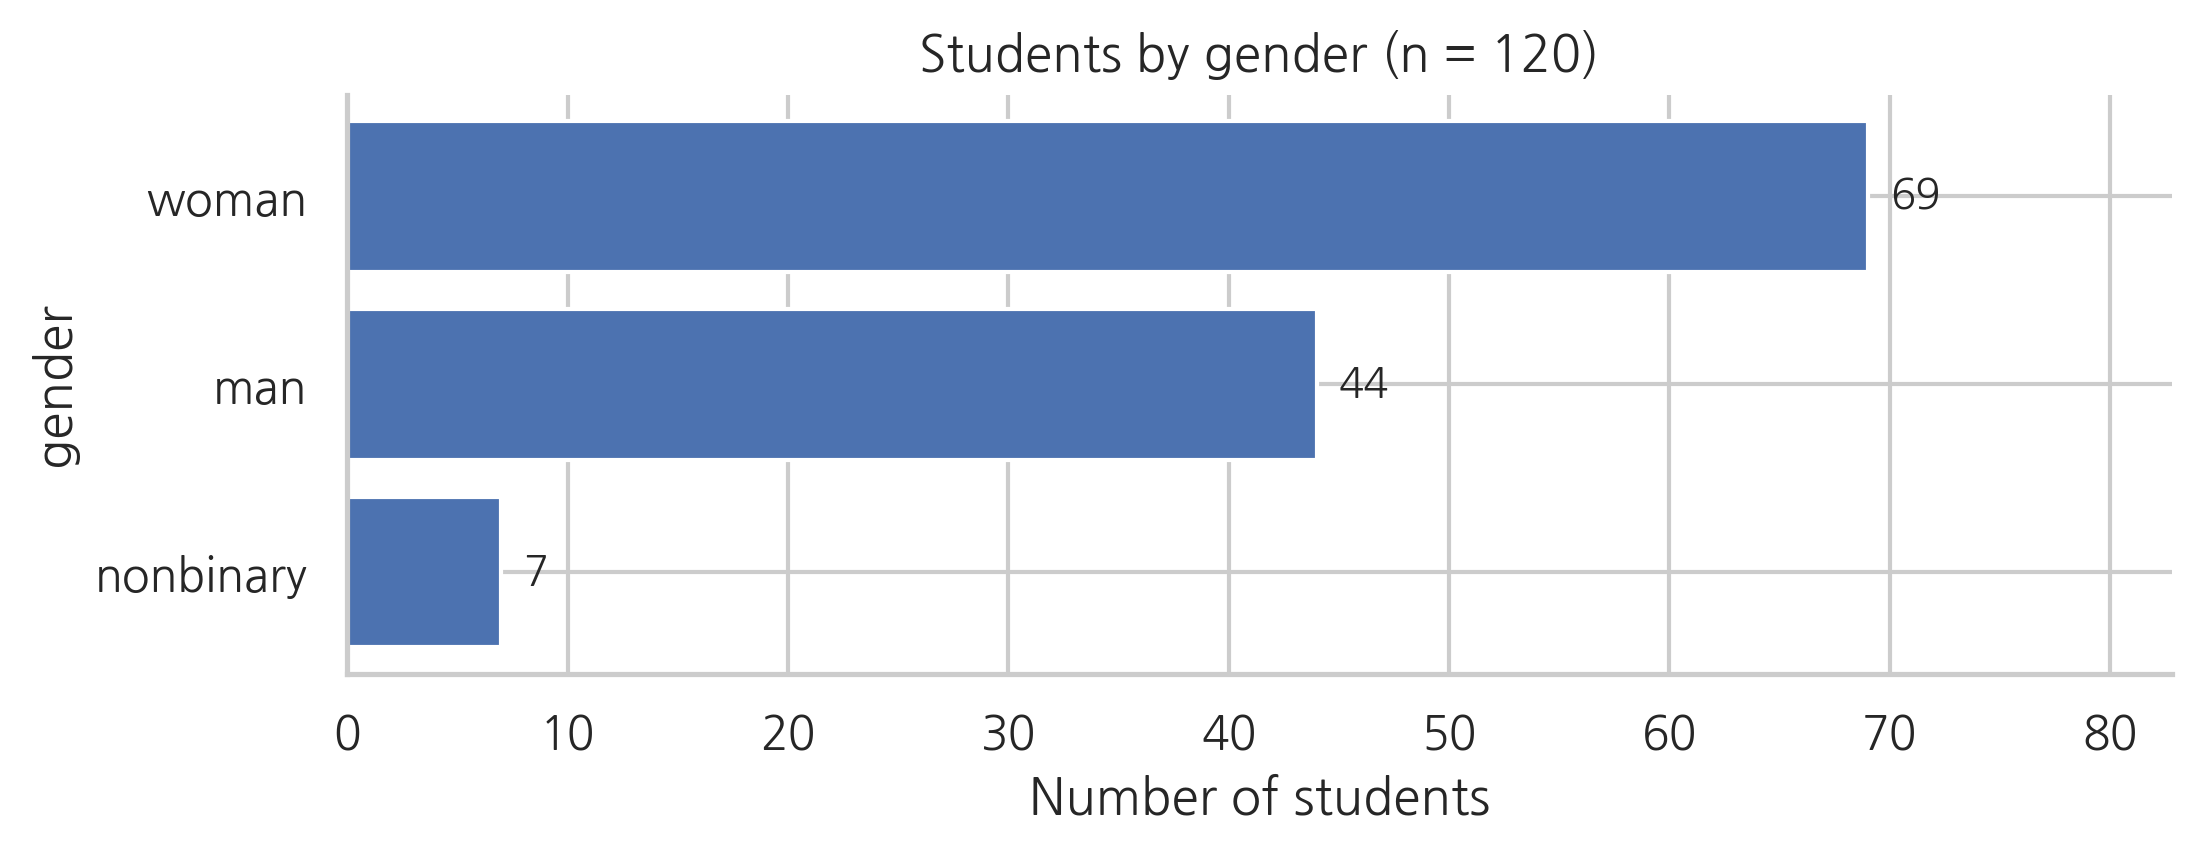

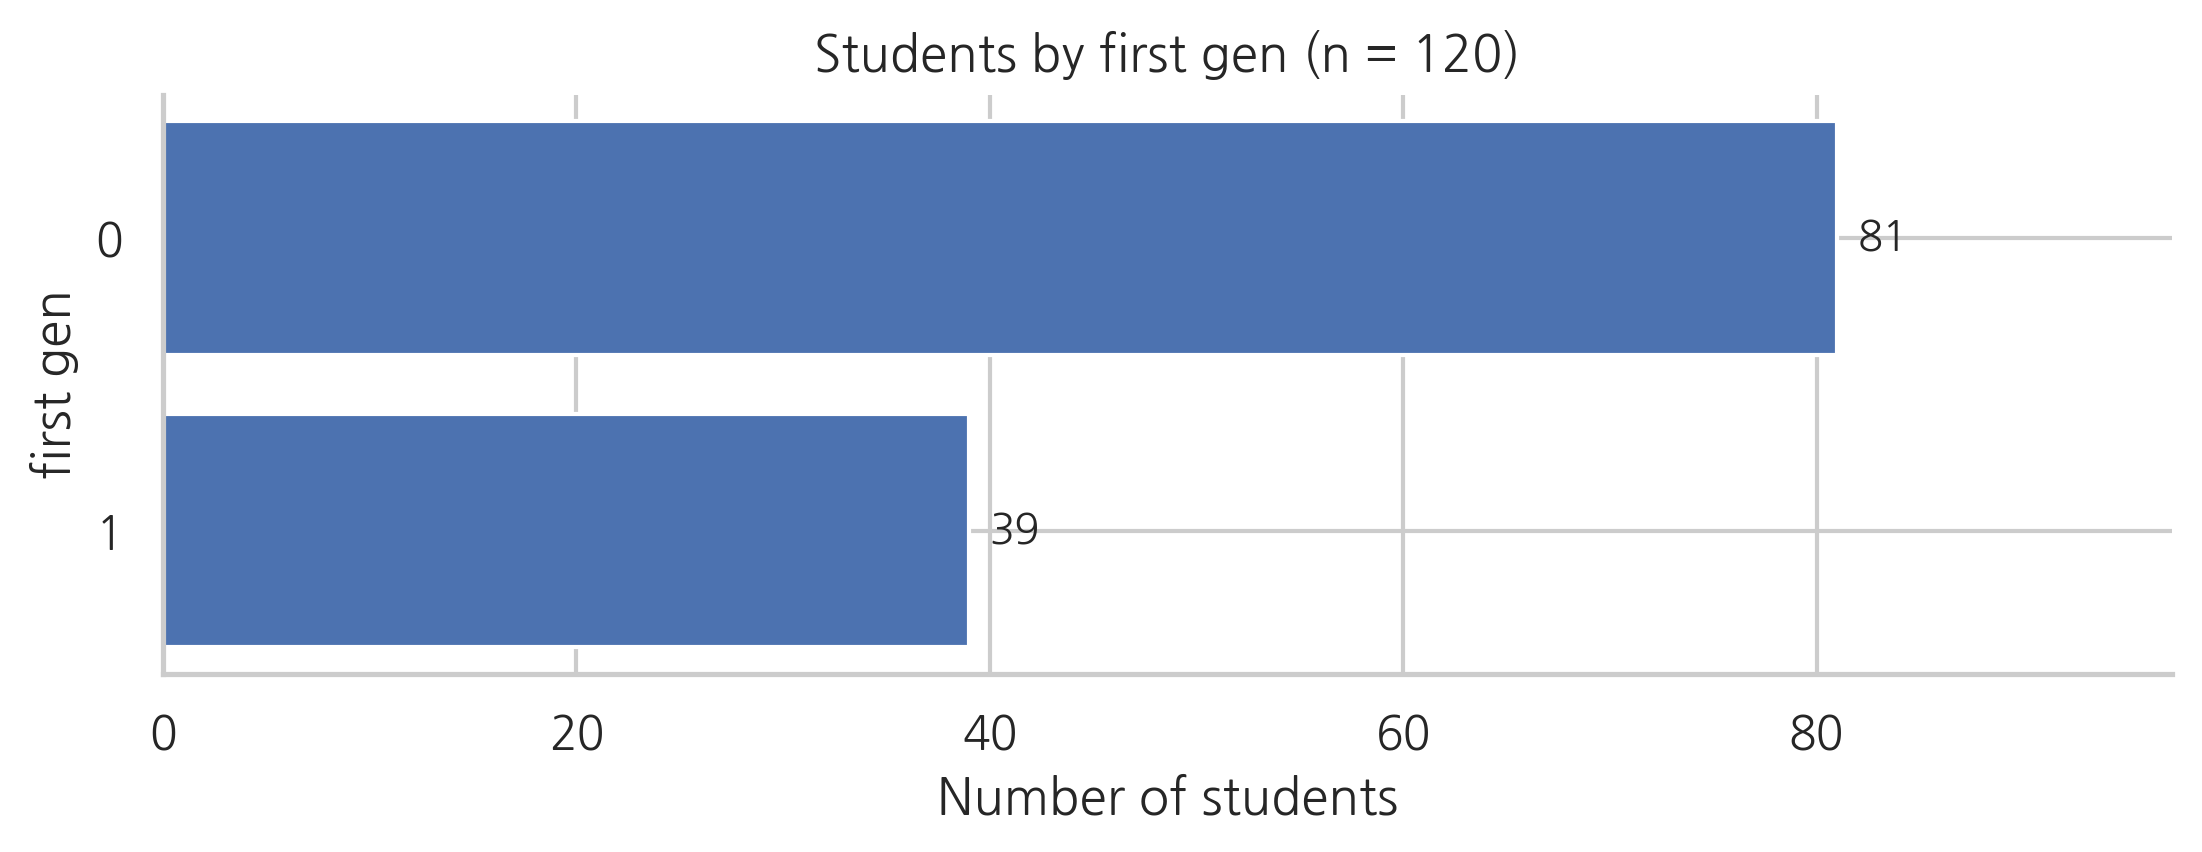

In [13]:
for column in ['gender', 'first_gen']:
    counts = students[column].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(7.5, 3))
    ax.barh(counts.index.astype(str), counts.values, color='#4C72B0')
    for y, v in enumerate(counts.values):
        ax.text(v + 1, y, str(v), va='center', fontsize=10)
    ax.set_title('Students by ' + column.replace('_', ' ') + ' (n = 120)')
    ax.set_xlabel('Number of students')
    ax.set_ylabel(column.replace('_', ' '))
    ax.set_xlim(0, counts.max() * 1.2)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

### Solution, Your turn 2

`MY_ASSESSMENT = 'final_project'` with `BIN_WIDTH = 5`. The final project is scored on a
different task than the quizzes, and its spread is noticeably tighter. Compare the std dev
below (about 10.6) with the quiz-wide 13.0 from Section 4. Comparing a tight distribution
with a wide one as if they were the same measurement is a mistake worth naming early.

The table underneath shows every assessment at once, which is the fastest way to see that
the class average barely moves across eight quizzes while the spread grows.

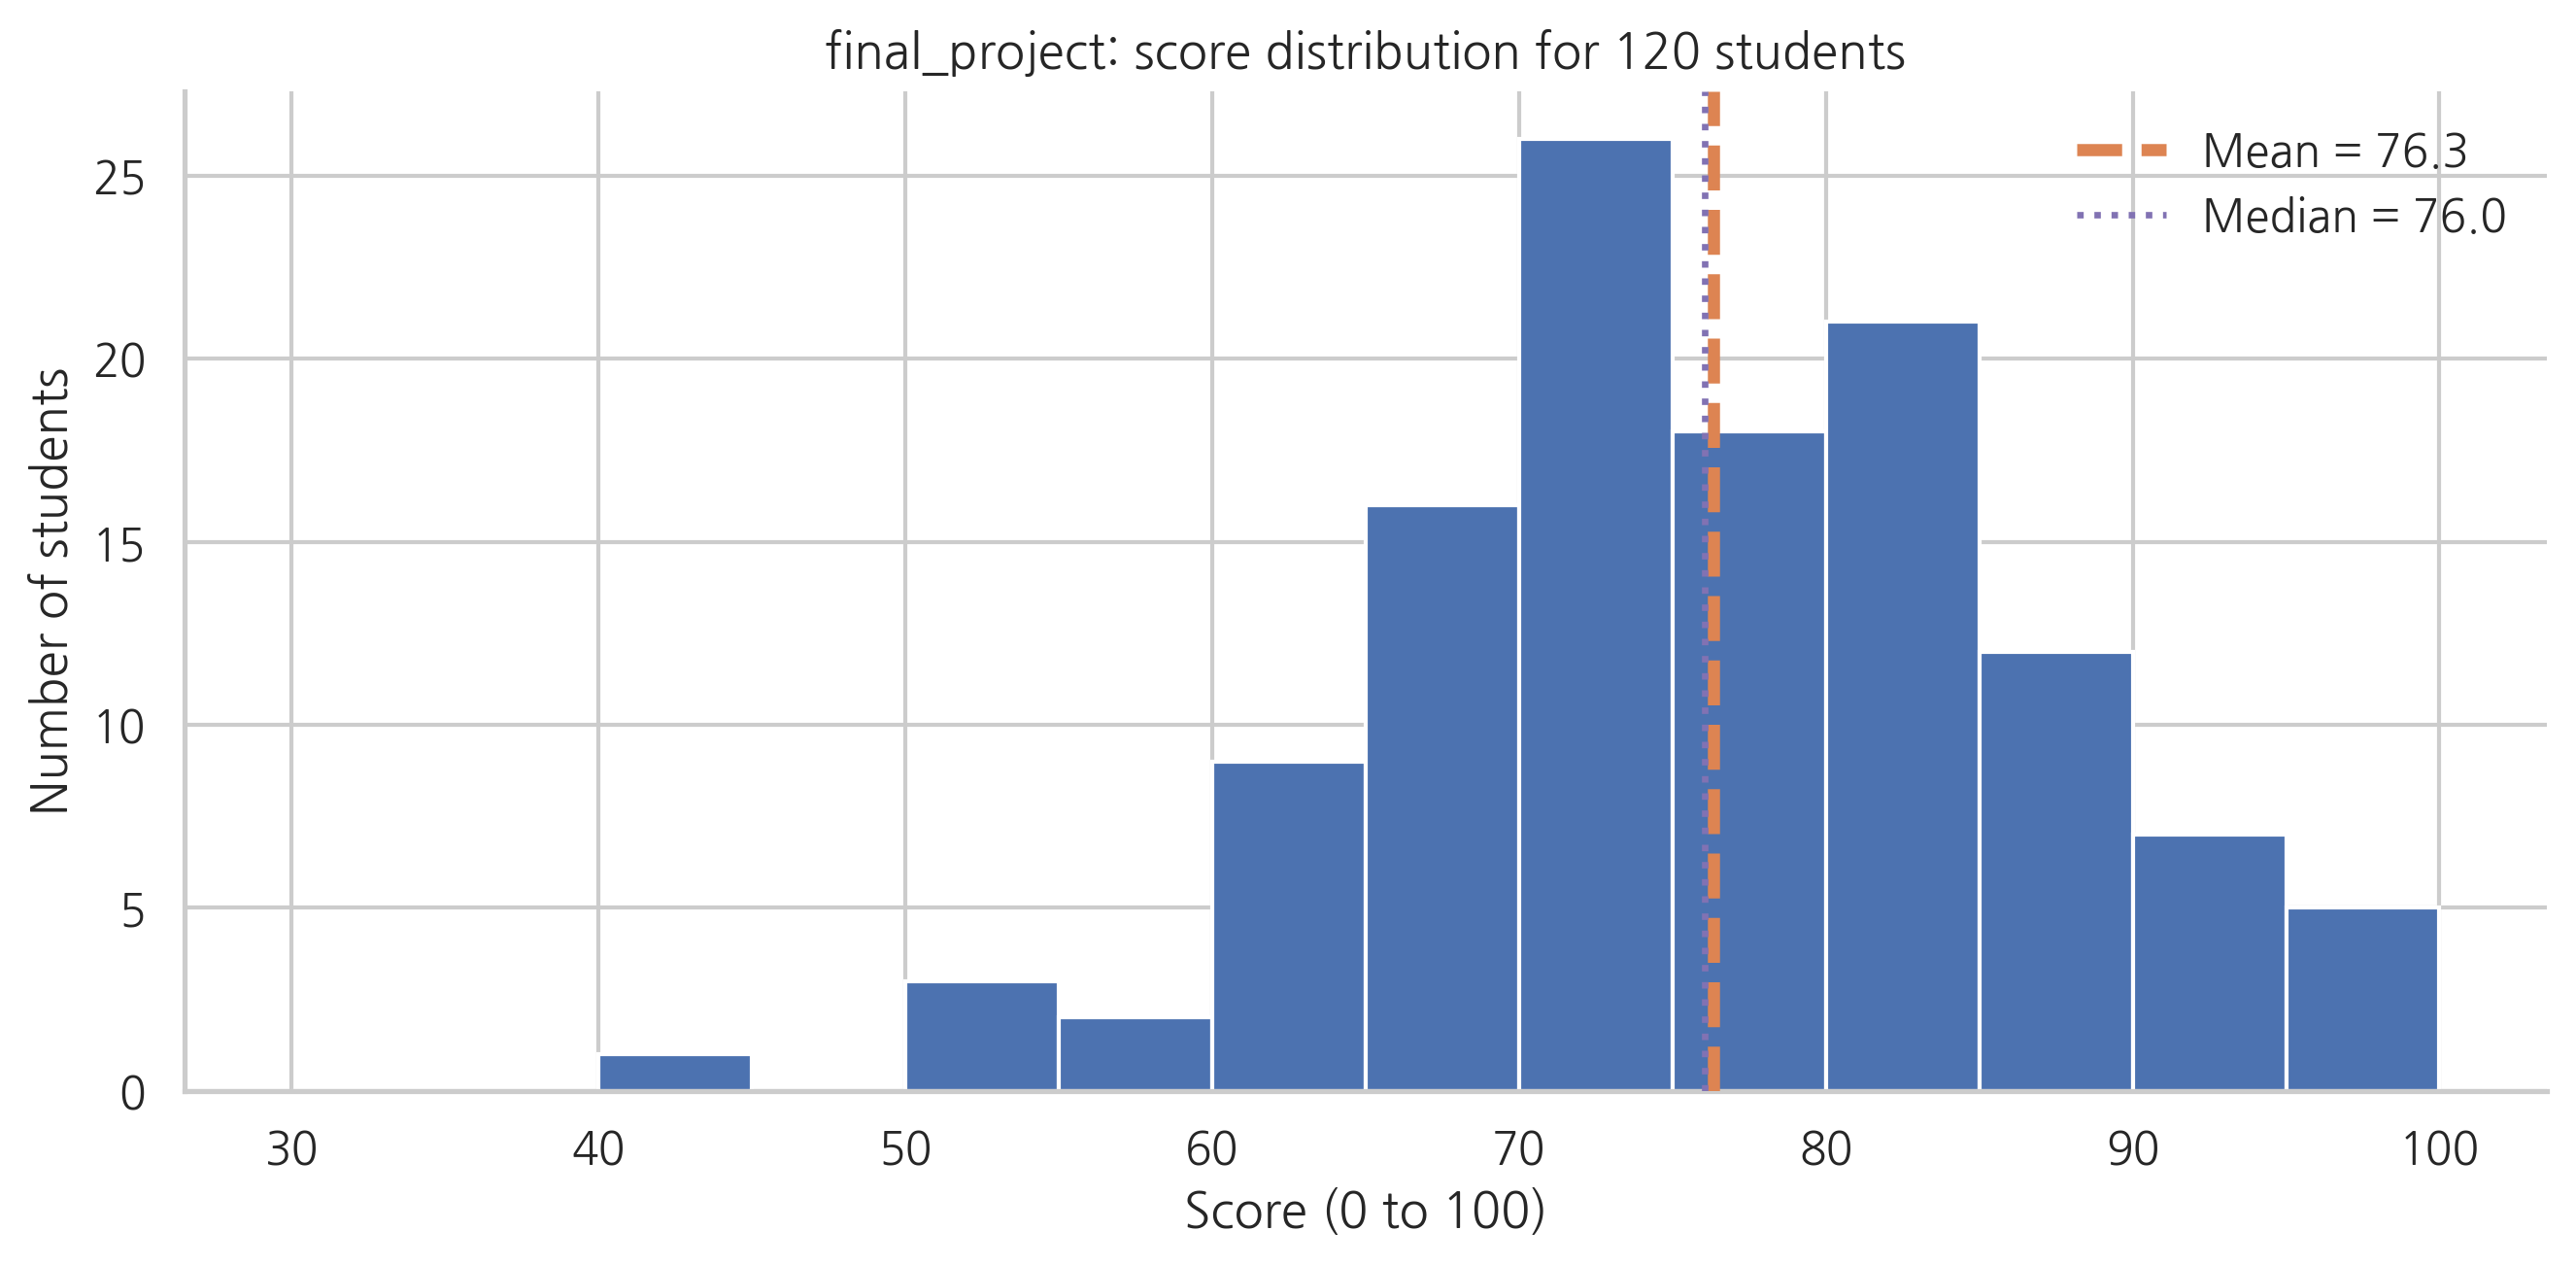

               count  mean   std   min    max
assessment                                   
final_project    120  76.3  10.6  41.7   99.1
quiz_1           120  77.8  11.1  43.1  100.0
quiz_2           120  75.8  12.3  44.4  100.0
quiz_3           120  72.5  12.1  43.6  100.0
quiz_4           120  74.9  12.6  35.2  100.0
quiz_5           120  78.4  12.1  47.0  100.0
quiz_6           120  73.5  13.5  36.4  100.0
quiz_7           120  76.0  14.3  33.8  100.0
quiz_8           120  77.1  14.7  34.6  100.0


In [14]:
final_scores = gradebook[gradebook['assessment'] == 'final_project']['score']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(final_scores, bins=np.arange(30, 105, 5), color='#4C72B0', edgecolor='white')
ax.axvline(final_scores.mean(), color='#DD8452', linestyle='--', linewidth=3.0, zorder=3,
           label='Mean = ' + str(round(final_scores.mean(), 1)))
ax.axvline(final_scores.median(), color='#8172B3', linestyle=':', linewidth=1.6, zorder=4,
           label='Median = ' + str(round(final_scores.median(), 1)))
ax.set_title('final_project: score distribution for 120 students')
ax.set_xlabel('Score (0 to 100)')
ax.set_ylabel('Number of students')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

per_assessment = (gradebook.groupby('assessment')['score']
                  .agg(['count', 'mean', 'std', 'min', 'max']).round(1))
print(per_assessment.to_string())

### Solution, Your turn 3

`STUDENT_A = 'S039'` and `STUDENT_B = 'S066'` is the opposite kind of pair: two students
whose averages are about 56 points apart. Putting them on the same axes makes a different
point from the matched pair in Section 5. Here the gradebook is telling you something real
and large, and the honest response is not "the average hides everything" but "the average
hides some things, and this is not one of them."

Knowing which situation you are in is the skill.

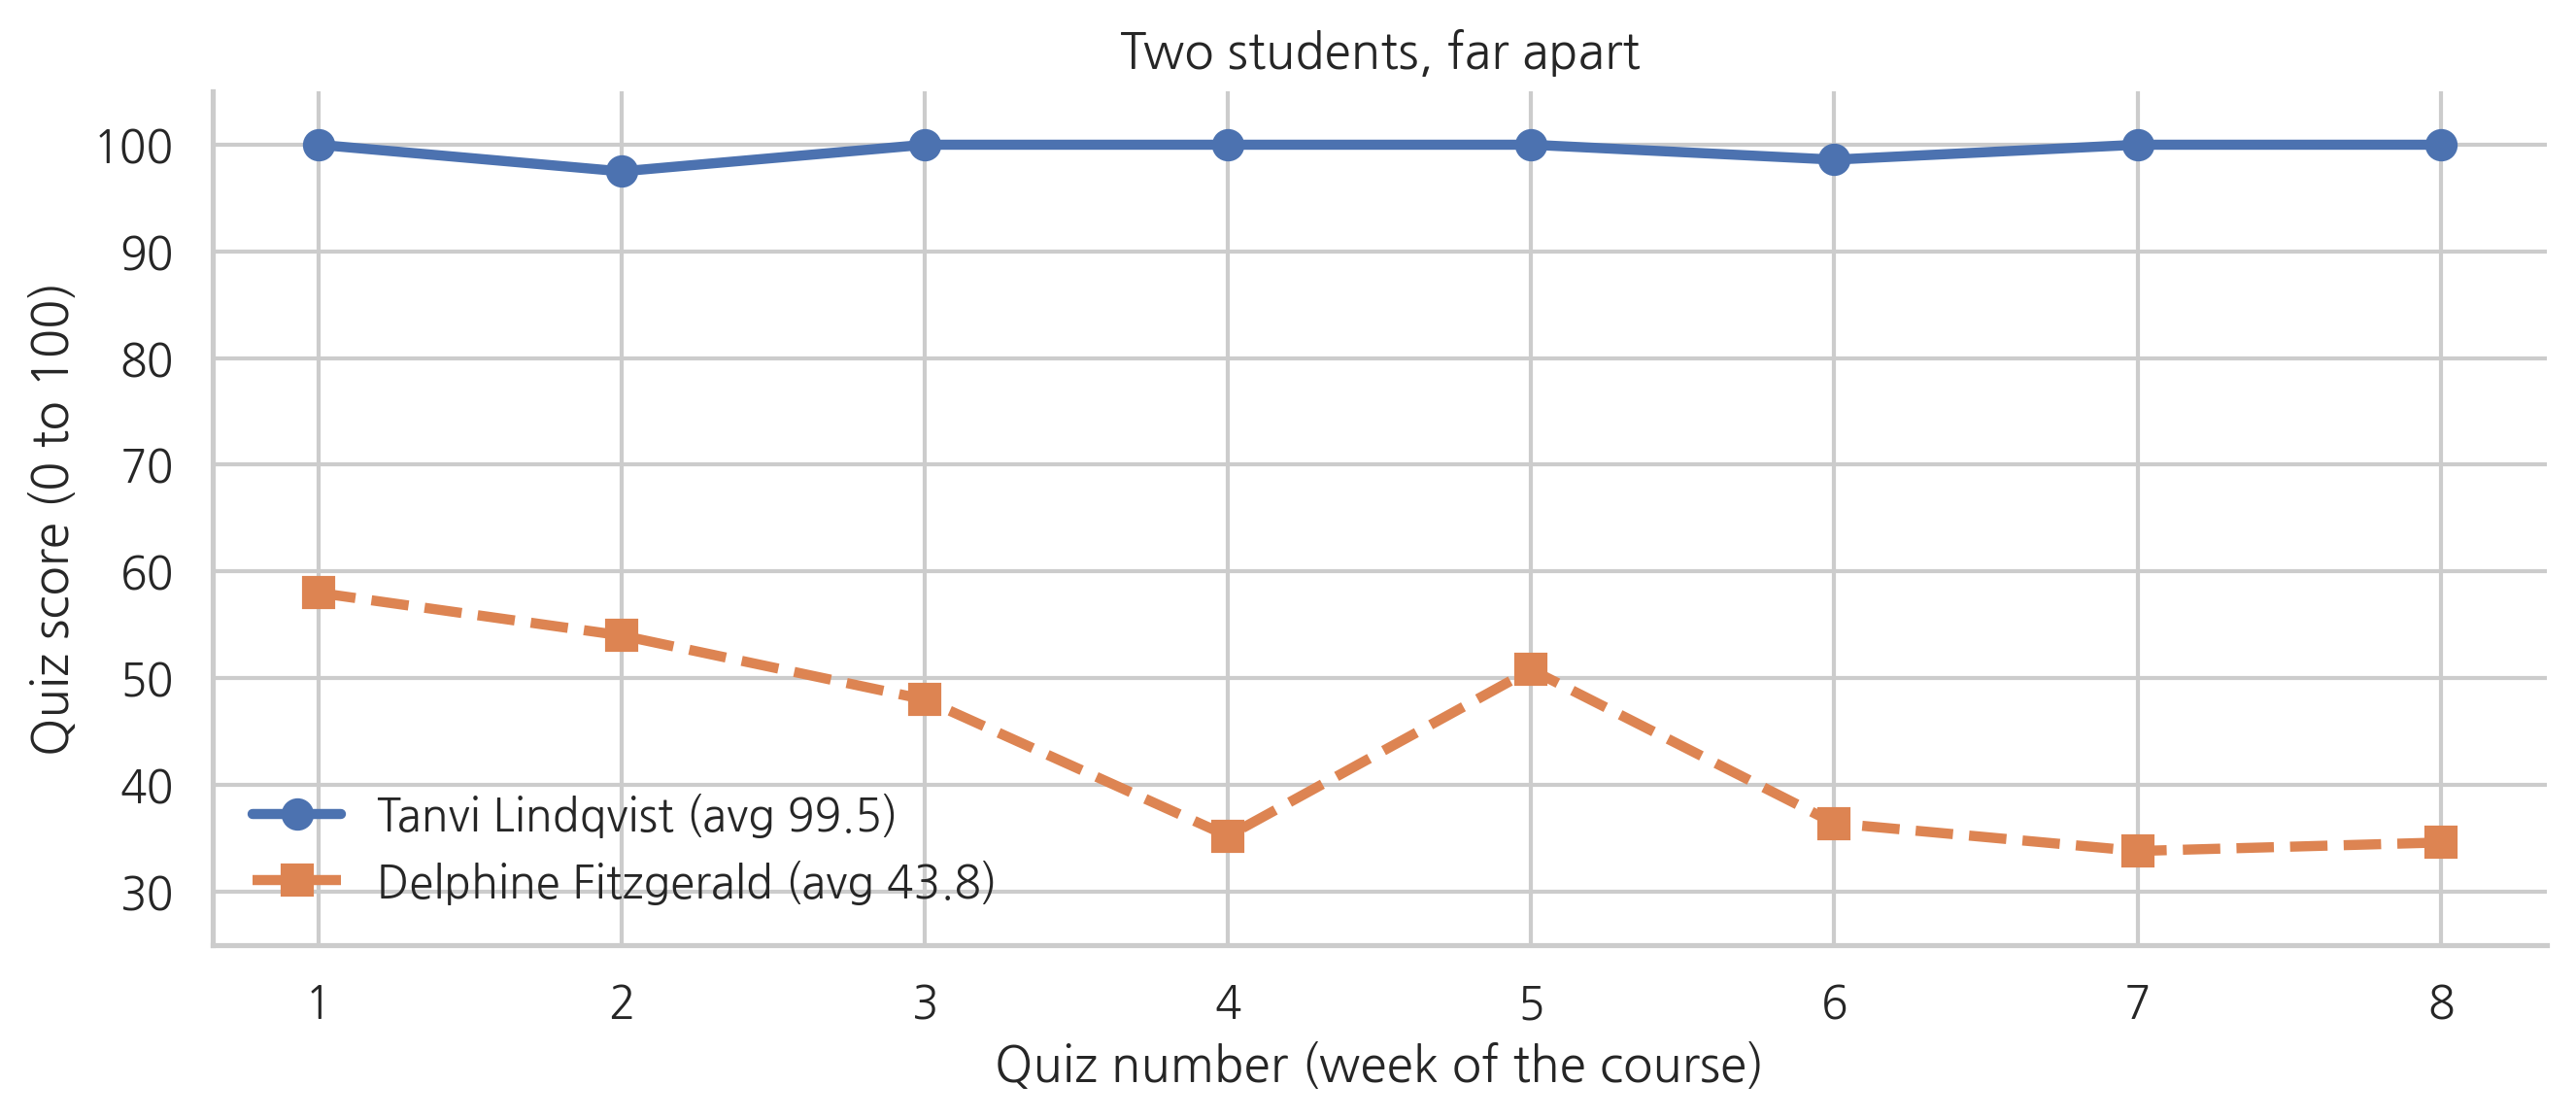

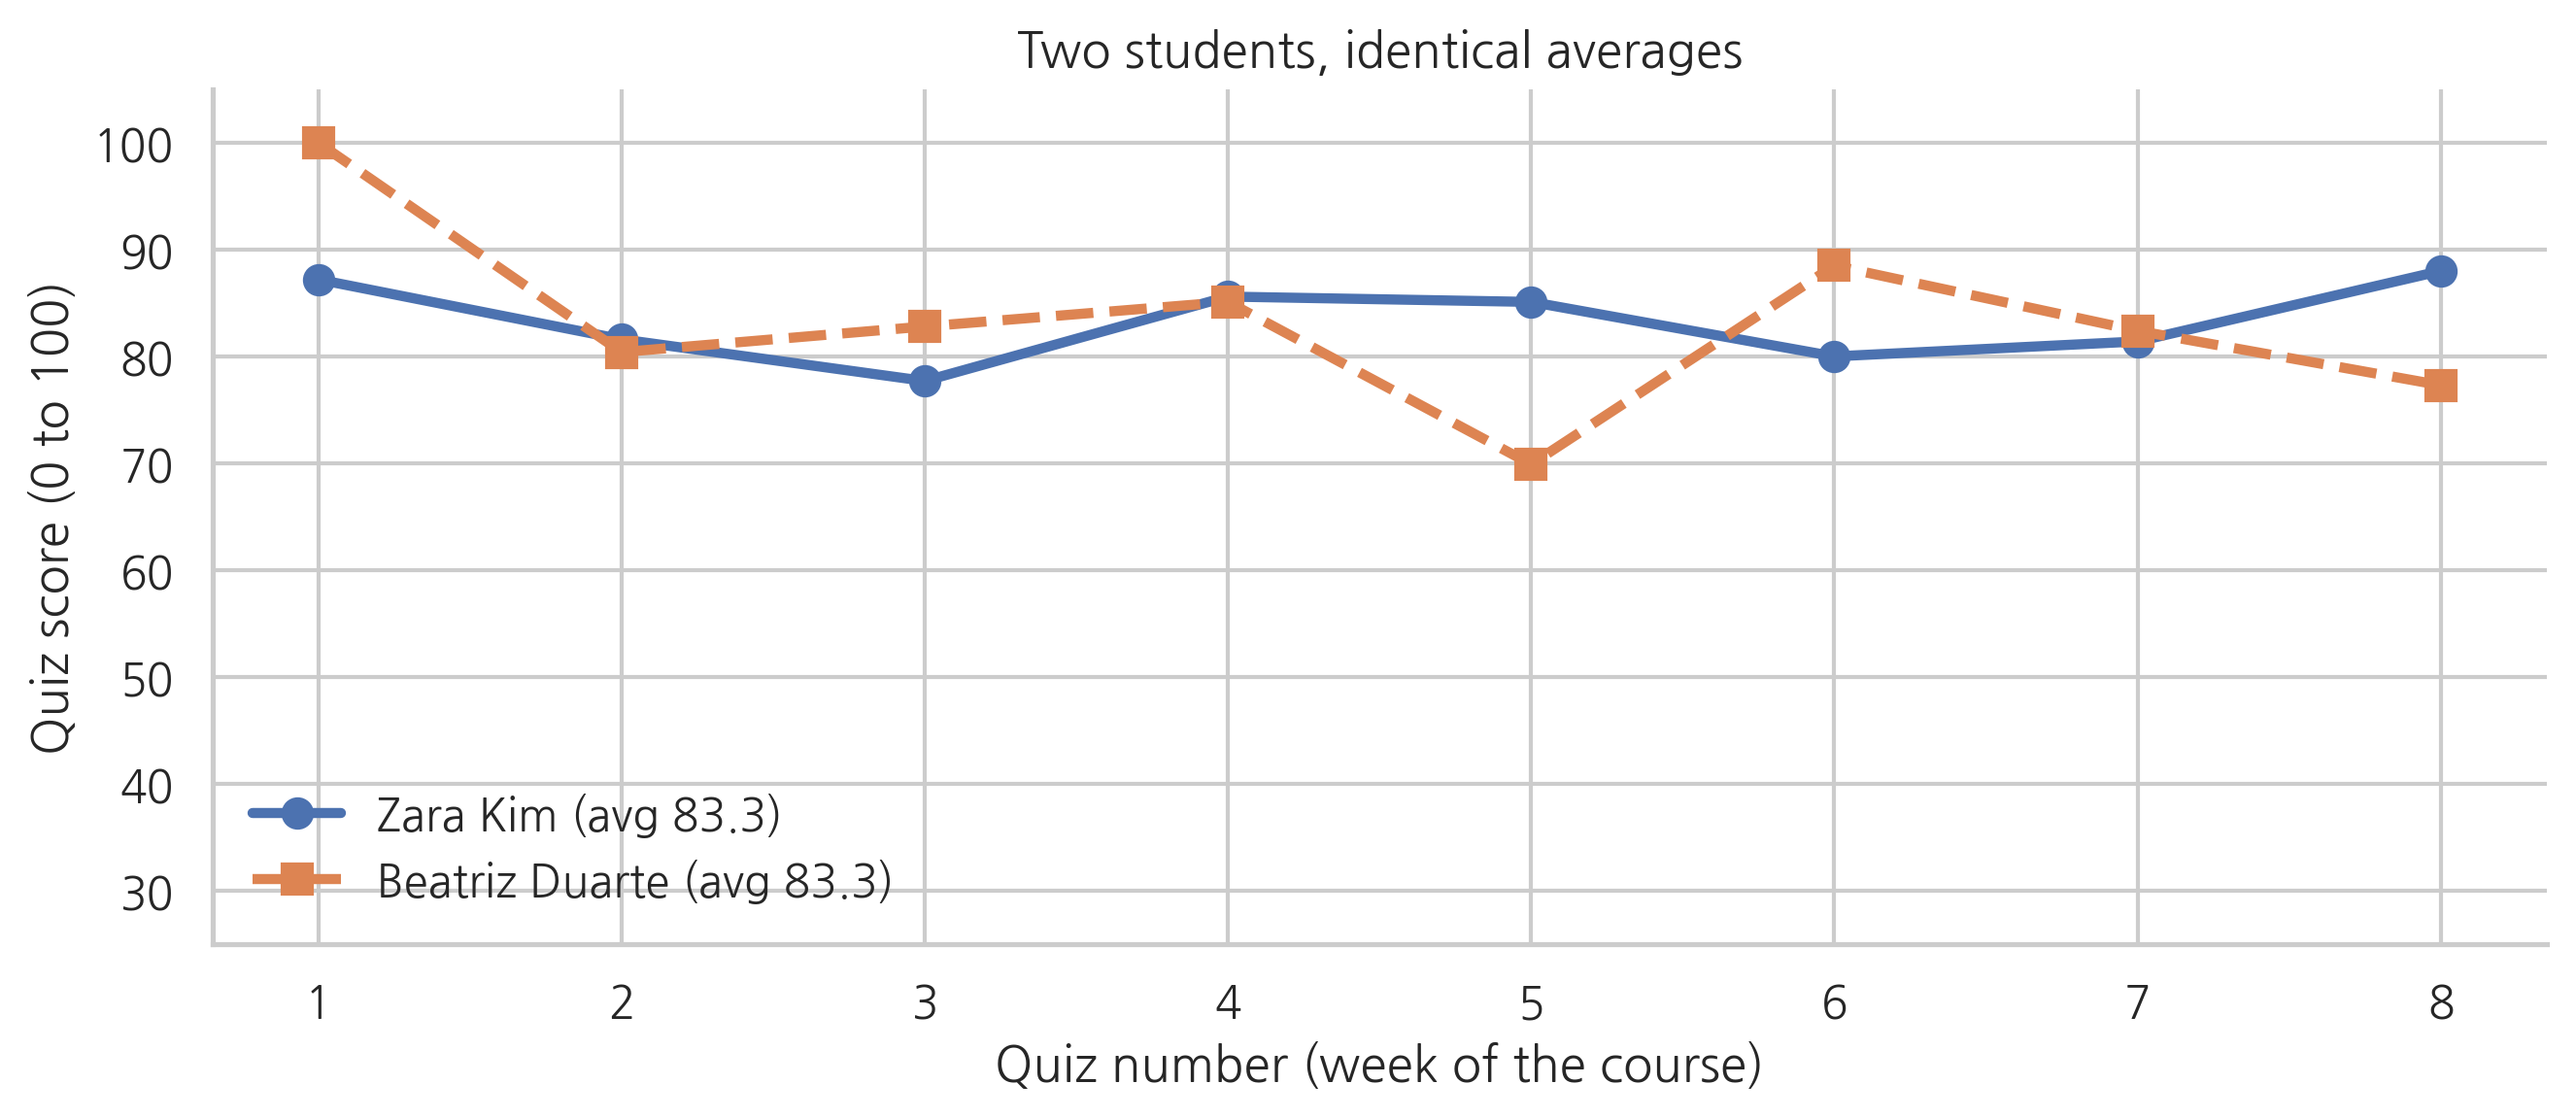

In [15]:
for sid_a, sid_b, note in [('S039', 'S066', 'far apart'), ('S016', 'S023', 'identical averages')]:
    a, b = wide.loc[sid_a], wide.loc[sid_b]
    la = names.loc[sid_a, 'first_name'] + ' ' + names.loc[sid_a, 'last_name']
    lb = names.loc[sid_b, 'first_name'] + ' ' + names.loc[sid_b, 'last_name']

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(wide.columns, a.values, marker='o', markersize=7, linewidth=2.5,
            color='#4C72B0', linestyle='-', label=la + ' (avg ' + str(round(a.mean(), 1)) + ')')
    ax.plot(wide.columns, b.values, marker='s', markersize=7, linewidth=2.5,
            color='#DD8452', linestyle='--', label=lb + ' (avg ' + str(round(b.mean(), 1)) + ')')
    ax.set_title('Two students, ' + note)
    ax.set_xlabel('Quiz number (week of the course)')
    ax.set_ylabel('Quiz score (0 to 100)')
    ax.set_xticks(wide.columns)
    ax.set_ylim(25, 105)
    ax.legend(frameon=False, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

---

### Where this goes next

Week 2 adds `lms_clickstream.csv`, roughly 41,000 recorded actions from the same 120
students, and asks the obvious follow-up: do students who do more in the course learn more?
Bring today's unanswerable question with you. Some of them stay unanswerable when the data
gets bigger, and noticing which ones do is the actual skill.

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee ·
University of Virginia. Data are synthetic, generated with numpy seed 8100. Treat them as
if they were real.*